# Expressing MiMo-V2.6-Pro

This notebook writes MiMo-V2.6-Pro, the open-weight model of Xiaomi, as one algebraic expression and draws it part by part against the reference implementation shipped in its checkpoint. It then derives the pass that reads the earlier tokens from caches, and writes the model and the pass into one interactive page. `notebooks/website/modern/validate_mimo_v26_pro.py` checks every fact the notebook states about the expression.

*Written by Claude Opus 5.5 (1M context) at effort 40 on 2026-09-28.*

In [1]:
import dataclasses

import notebooks.display.notebook_diagrams as notebook_diagrams
import notebooks.display.sota_figures as figures
import notebooks.sota.MiMoV26Pro.assemble_page_variants as assemble_page_variants
import notebooks.sota.MiMoV26Pro.derive_cached_mimo_v26_pro as derive_cached_mimo_v26_pro
import notebooks.sota.MiMoV26Pro.operator_explanations as operator_explanations
import notebooks.sota.MiMoV26Pro.released_constants as released_constants
import notebooks.sota.MiMoV26Pro.rotary_embedding as rotary_embedding
import notebooks.sota.MiMoV26Pro.slide_causal_reads as slide_causal_reads
import notebooks.sota.MiMoV26Pro.whole_model as whole_model
import notebooks.website.website_output as website_output
from IPython.display import Markdown, display
from notebooks.sota.MiMoV26Pro.block_titles_and_descriptions import TEXT as text

DIAGRAMS = operator_explanations.with_explanation_tables(
    figures.DiagramSettings(
        mode=figures.DiagramMode.INLINE,
        dark_mode=notebook_diagrams.ColorMode.LIGHT,
        tape=figures.TapePresentation.ABSORBED,
        axis_sizes=figures.AxisSizes.SUBSCRIPT,
        axis_label_font_size=0.8,
        block_recycling=figures.BlockRecycling.RECYCLED,
        advanced_display=figures.AdvancedDisplay.LEGEND,
        expanded_parameters=figures.ExpandedParameters.WEIGHT_ARRAYS,
        title='MiMo-V2.6-Pro'))
PAGE = dataclasses.replace(
    assemble_page_variants.page_settings(figures.DiagramMode.HTML),
    page_directory=website_output.MODERN_PAGES)

figures.forget_drawn_blocks()

DECODE = slide_causal_reads.mimo_slid
CACHED = derive_cached_mimo_v26_pro.cached_mimo
assigned_sizes = whole_model.released_assigned_sizes()
cached_sizes = derive_cached_mimo_v26_pro.cached_assigned_sizes()

## Reading the figures

A figure is a neural circuit diagram of one expression. Every wire is an array, and the label on a wire names the axes of that array with the size of each axis written as a subscript. An operator is a shape drawn across its operands and its results. A wire passes through an operator when the operator is broadcast over the axis of that wire, and a broadcast operator computes the same function separately at every index of the axis. A wire ends at an operator when the operator consumes the axis, and the function of the operator then reads every index of the axis together. A linear map of the hidden state is the same map at every token, so it is broadcast over the token axis. The rotary embedding turns every token by an angle that grows with the position of the token, so the rotation consumes the token axis.

A block is a titled box around a part of the expression, and a block whose repetition is greater than one denotes a loop. A box is drawn beside its body the first time that body appears and as the box alone afterwards, so a mechanism is explained once and referred to later, and the figures below are ordered so that each one introduces the bodies used by the next. On the interactive page, resting the pointer over a box or an operator opens an inspection box with its formula, a description and a link to the lines of the reference expressed by it.

No size appears in the expression. Each axis carries a free symbol, and the sizes of the configuration are written onto the labels when a figure is drawn, so a formula reads with its symbols and one table binds the numbers.

| axis | size | what it indexes |
| --- | --- | --- |
| `x`, `v` | symbolic, 152576 | the token positions of the prompt, and the vocabulary |
| `m` | 6144 | the width of the residual |
| `h`, `g` | 8, 16 | the key-value heads, and the query heads that read each of them |
| `t`, `c`, `p` | 32, 2, $2 \lvert t \rvert$ | the pairs of turned channels, the two halves the reference holds them in, and the turned channels |
| `n`, `a` | 128, $\lvert p \rvert + \lvert n \rvert$ | the channels of a query head or a key head that are not turned, and the whole head |
| `u` | 128 | the channels of a value head |
| `r`, `w` | $\lvert x \rvert$, 128 | the distance counted back from a query in a full attention layer, and a slot of the window of a sliding window layer |
| `e`, `k`, `f` | 384, 8, 2048 | the routed experts, the experts kept for one token, and the width of an expert |
| `d` | 16384 | the width of the dense MLP |

The size of `c` is 2 whatever the configuration, because one half holds the real parts of the turned pairs and the other half their imaginary parts.

Two of those axes hold a value at some of their positions and nothing at the others, and the position of the query decides which. The distance axis `r|x` counts back from a query, so distance $i_{r}$ of query $i_{x}$ holds a value when $i_{x} - i_{r} \geq 0$. The window axis `w|x` counts back the same way over 128 slots, so slot $i_{w}$ of query $i_{x}$ holds a value when $i_{x} - i_{w} \geq 0$, and the first 127 queries of a prompt hold nothing at the last slots of their window. A position holding nothing holds the universal unit. Every sum, maximum and contraction ignores the unit, and every elementwise map preserves it, so causality is stated once, at the view that reads back from a query, and reaches every consumer with no mask written anywhere.

Beside each figure stands a legend with one row per named axis of the term. The axis stands on the left, the integer of its size in the middle, and on the right the code form carried by its name, which is the name of the axis in generated code.

Every constant of the reference is a named symbol in the expression as well, so no size assigned to an axis can reach a constant. The table below gives the value of each symbol in the reference and the line that sets it.

In [2]:
display(Markdown(released_constants.released_constants_table()))

| symbol | value in the reference | meaning | line |
|---|---|---|---|
| $\beta$ | $10^{7}$ | the rotary base of the full attention layers, `rope_theta`, which sets how slowly the slowest pair of channels turns | [config.json L365](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L365) |
| $\beta_{\mathrm{w}}$ | $10^{4}$ | the rotary base of the sliding window layers, `swa_rope_theta` | [config.json L373](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L373) |
| $\varepsilon$ | $10^{-5}$ | the number added under the square root of every RMS normalisation, `layernorm_epsilon` | [config.json L122](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L122) |
| $\varepsilon_{\mathrm{r}}$ | $10^{-20}$ | the number added to the sum of the eight kept gates before each gate is divided by that sum | [modeling_mimo_v2.py L181](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L181) |
| $\lambda$ | $0.612$ | the factor `attention_value_scale`, which multiplies every value before the attention reads it | [config.json L11](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L11) |

## MiMo-V2.6-Pro and its reference implementation

MiMo-V2.6-Pro is a decoder-only transformer of 70 layers with a residual width of 6,144 and a vocabulary of 152,576 tokens ([config.json L204](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L204), [config.json L45](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L45), [config.json L440](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L440)). Sixty of its layers attend to the 128 tokens ending at each query through a sliding window, and ten attend to every token at or before the query ([config.json L47-L118](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L47-L118), [config.json L368](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L368)). Every layer runs grouped-query attention with 128 query heads and 8 key-value heads ([config.json L202](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L202), [config.json L205](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L205)). Layer 0 ends in a dense MLP, and layers 1 to 69 end in a mixture of 384 routed experts, of which 8 run per token, with no shared expert ([config.json L126-L197](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L126-L197), [config.json L199-L200](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L199-L200), [config.json L203](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L203)). The context runs to 1,048,576 tokens ([config.json L123](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L123)). The model card gives 1.02 trillion parameters, of which 42 billion run for one token ([README L94](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/README.md#L94)).

The reference implementation is the remote code shipped in the checkpoint. The `auto_map` of the configuration names `MiMoV2ForCausalLM` in `modeling_mimo_v2.py` ([config.json L34-L38](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L34-L38)), and `transformers` loads that file with the weights. The configuration was written by `transformers` 5.3.0 ([config.json L378](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L378)). The remote code takes its attention masks and its cache from that library, so the notebook also reads the two files of `transformers` 5.3.0 that decide what a sliding window reads and what its cache keeps. Serving frameworks such as SGLang and vLLM run the same checkpoint with kernels of their own ([README L153-L203](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/README.md#L153-L203)), and the section *Facts left unstated by the figures* lists what the notebook leaves out.

The checkpoint read here is `XiaomiMiMo/MiMo-V2.6-Pro-MOPD` at the commit `adea8e2c5373`, created on 2026-09-27. It continues the training of `XiaomiMiMo/MiMo-V2.6-Pro-RL` ([README L60-L66](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/README.md#L60-L66)), and its `config.json`, `configuration_mimo_v2.py` and `modeling_mimo_v2.py` are byte-identical to those of the RL checkpoint at the commit `73875d00b30a`. The technical report, [MiMo_V2_6_technical_report.pdf](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-RL/blob/73875d00b30a89ef8cc353a0b60b0e9f9561952d/MiMo_V2_6_technical_report.pdf), stands in the repository of the RL checkpoint.

The checkpoint also holds a vision encoder and two audio encoders. The reference replaces the embeddings of the image, video and audio tokens of a prompt with the outputs of those encoders ([L1827-L1836](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1827-L1836), [L1758-L1803](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1758-L1803)), and the expression holds the text path alone. The checkpoint holds a drafter of five layers for speculative decoding as well ([README L99](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/README.md#L99)). The reference skips the weights of the drafter when it loads the checkpoint ([L1690-L1695](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1690-L1695)), so the expression holds no drafter.

## The rotary embedding

The rotary embedding turns part of every query and every key through an angle growing with the position of its token, so that the score of a query against a key depends on the distance between the two tokens ([L47-L60](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L47-L60), [L445-L505](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L445-L505)). MiMo-V2.6-Pro turns the first 64 of the 192 channels of every query head and every key head, which is `int(head_dim * partial_rotary_factor)` for a factor of 0.334 ([L253](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L253), [config.json L207](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L207)). The other 128 channels pass through, and the turned channels come first when the two parts are joined ([L306-L310](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L306-L310)).

The reference builds two tables of turns ([L1596-L1597](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1596-L1597)). The full attention layers read a table at the base $\beta = 10^{7}$, `rope_theta`, and the sliding window layers read a table at the base $\beta_{\mathrm{w}} = 10^{4}$, `swa_rope_theta` ([L459-L463](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L459-L463), [config.json L365](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L365), [config.json L373](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L373)). Each table holds 32 frequencies, and its entry at position $i_{x}$ and pair $i_{t}$ is $F[i_{x}, i_{t}] = e^{\mathrm{i}\, i_{x}\, \theta[i_{t}]}$ for the frequency $\theta[i_{t}] = \beta^{-i_{t}/\lvert t \rvert}$ ([L474-L490](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L474-L490)). The configuration passes its `rope_parameters` to the constructor as `rope_scaling` ([configuration L133-L135](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/configuration_mimo_v2.py#L133-L135)), which names the default rotary embedding, so neither table is rescaled.

`rotate_half` pairs channel $i_{t}$ of the first 32 turned channels with channel $\lvert t \rvert + i_{t}$ of the last 32, the first as the real part of a complex number and the second as its imaginary part ([L47-L51](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L47-L51), [L58-L59](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L58-L59)). The expression writes the two halves into the rows of the projections of the turned channels, as the axis $c$, so entry $(i_{c}, i_{t})$ of a projection is channel $i_{t} + \lvert t \rvert\, i_{c}$ of the reference. That grouping is written into the linear map, per the ruling on groupings in `obsidian/06-practice/Representing Models.md`. Inside the box, the covariant view named Pairs writes entry $(i_{c}, i_{t})$ at channel $2 i_{t} + i_{c}$. `dst.PairsAsComplex` reads each two adjacent channels as one complex number, the product with the table turns it, and `dst.Decomplex` writes each turned pair back as two adjacent channels:

$$y[i_{x}, 2 i_{t}] + \mathrm{i}\, y[i_{x}, 2 i_{t} + 1] = F[i_{x}, i_{t}]\, \big(v[i_{x}, 0, i_{t}] + \mathrm{i}\, v[i_{x}, 1, i_{t}]\big).$$

The reference writes the turned pairs back as two halves, where the box writes each pair back in place. The query and the key are written in the same order, so every score is unchanged. The cache of the pass over new tokens holds the numbers the reference caches, in the order of the pairs.

The rotary embedding of the full attention layers, drawn as its box beside its body: the two halves of the 64 turned channels written in the order of the pairs, the pairs read as 32 complex numbers, the table of turns as a circle, the product, and the pairs written back as channels.


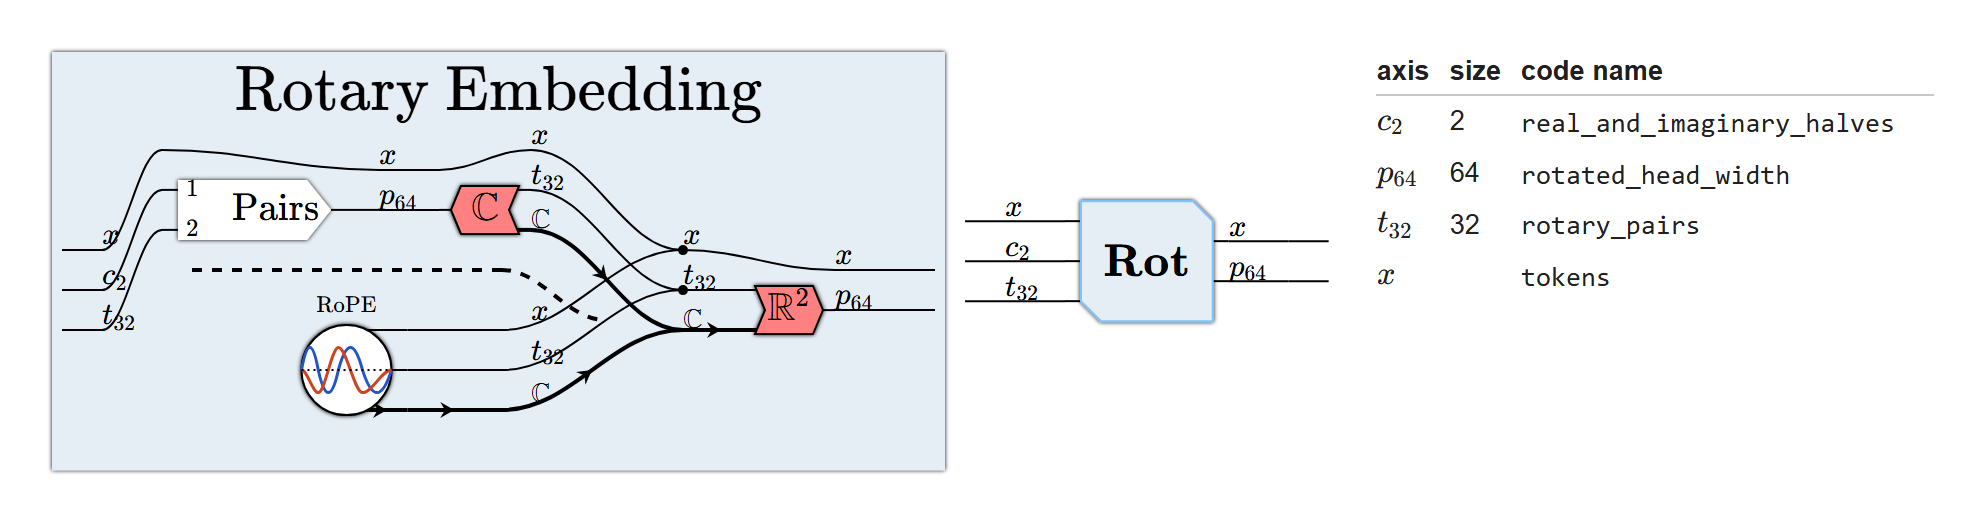

The rotary embedding of the sliding window layers, whose table of turns is built at the base beta_w.


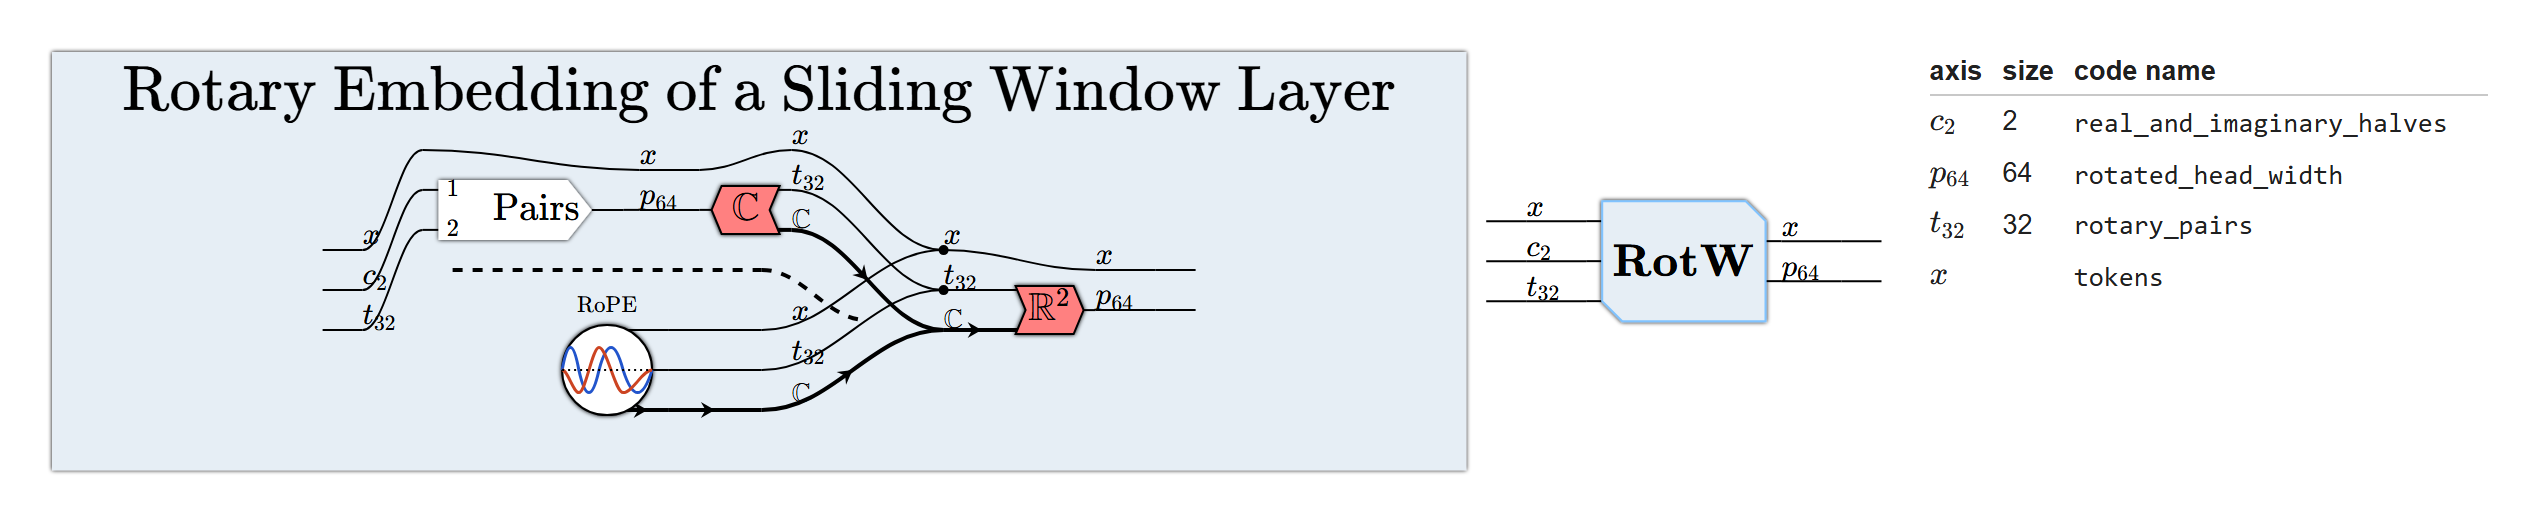

In [3]:
await figures.show(
    rotary_embedding.ROTATE_FULL_ATTENTION_CHANNELS,
    'The rotary embedding of the full attention layers, drawn as its box beside its '
    'body: the two halves of the 64 turned channels written in the order of the pairs, '
    'the pairs read as 32 complex numbers, the table of turns as a circle, the product, '
    'and the pairs written back as channels.',
    width=1200, sub_blocks=figures.SubBlocks.EVERY_BODY,
    assigned_sizes=assigned_sizes, settings=DIAGRAMS)

await figures.show(
    rotary_embedding.ROTATE_SLIDING_WINDOW_CHANNELS,
    'The rotary embedding of the sliding window layers, whose table of turns is built '
    'at the base beta_w.',
    width=1200, sub_blocks=figures.SubBlocks.EVERY_BODY,
    assigned_sizes=assigned_sizes, settings=DIAGRAMS)

## Reading back from each query

A query reads the keys and the values of the tokens at or before it. The expression states that restriction with a read of the token axis. In a full attention layer, the view named Back reads an array over the tokens at token $i_{x} - i_{r}$ for every distance $i_{r}$ of every query $i_{x}$, so it returns an array over the queries and the distances counted back from each. A distance that counts back past the first token names a negative token, and a read outside an axis holds the universal unit. The distance axis therefore leaves the view as `r|x`, carrying the affine form $i_{x} - i_{r} \geq 0$ that says which distances hold a value. The reference states the same restriction as the causal mask of `create_causal_mask` ([L1652](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1652)).

In a sliding window layer, the view named Window reads token $i_{x} - i_{w}$ for every slot $0 \le i_{w} < 128$ of every query $i_{x}$, so slot 0 is the query's own token and slot 127 the token 127 places before it. The reference builds its window with `create_sliding_window_causal_mask` ([L1654-L1657](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1654-L1657)), which in `transformers` 5.3.0 keeps key $k$ for query $q$ where $k \le q$ and $k > q - 128$ ([masking_utils.py L74-L77](https://github.com/huggingface/transformers/blob/aad13b87ed59f2afcfaebc985f403301887a35fc/src/transformers/masking_utils.py#L74-L77), [masking_utils.py L90-L99](https://github.com/huggingface/transformers/blob/aad13b87ed59f2afcfaebc985f403301887a35fc/src/transformers/masking_utils.py#L90-L99), [masking_utils.py L114-L118](https://github.com/huggingface/transformers/blob/aad13b87ed59f2afcfaebc985f403301887a35fc/src/transformers/masking_utils.py#L114-L118), [masking_utils.py L1099](https://github.com/huggingface/transformers/blob/aad13b87ed59f2afcfaebc985f403301887a35fc/src/transformers/masking_utils.py#L1099)). Those are the same 128 tokens. The reference adds either mask to the scores in its eager attention ([L84-L87](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L84-L87)). `transformers` runs the eager attention for this model, because `MiMoV2ForCausalLM` does not declare support for SDPA ([modeling_utils.py L1145](https://github.com/huggingface/transformers/blob/aad13b87ed59f2afcfaebc985f403301887a35fc/src/transformers/modeling_utils.py#L1145), [modeling_utils.py L1910-L1942](https://github.com/huggingface/transformers/blob/aad13b87ed59f2afcfaebc985f403301887a35fc/src/transformers/modeling_utils.py#L1910-L1942)).

An operation broadcast over the tokens computes the same function at every token. Reading its result at token $i_{x} - i_{r}$ therefore gives the values that reading its operand at $i_{x} - i_{r}$ and computing the operation at every query and distance gives. The figures below place every read back as early as it can stand, which is at the copy of the normalised hidden state that also feeds the queries. The key and value projections, the value scale and the rotation of the keys are then drawn over the queries and the slots. That arrangement of the expression is called the CausalSlide. It changes no value computed by the expression, because every operation passed by the read computes the same function at every token. The rotation of the keys is a function of the position, so its box reads its table of turns back through the same view. In each layer the key branch and the value branch ask the hidden state for the same read, and one read serves both.

## The queries, the keys and the values

The reference projects the normalised hidden state of every token onto the queries, the keys and the values with one weight, `qkv_proj`, and cuts the result into the three with `torch.split` ([L278-L283](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L278-L283), [L370-L372](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L370-L372)). It then cuts each query head and each key head into the 64 channels it turns and the 128 it passes through ([L306-L307](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L306-L307)). A linear map followed by a cut of its results is one linear map per part, so the expression holds five weights: $W^{Qr}$ and $W^{Qn}$ for the turned and the other channels of every query head, $W^{Kr}$ and $W^{Kn}$ for those of every key head, and $W^{V}$ for the values. The attention has no bias ([config.json L7](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L7)).

The 128 query heads are written as 8 groups of 16 over the axes $h$ and $g$. The reference repeats each of its 8 key heads and 8 value heads 16 times with `repeat_kv`, so query head $16 i_{h} + i_{g}$ reads key head $i_{h}$ ([L63-L68](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L63-L68), [L82-L83](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L82-L83)). The grouping is written into the query projections, so no view groups the heads, and every query head of group $i_{h}$ reads the key and the value of head $i_{h}$ in the attention core.

A query head and a key head each join their 64 turned channels and their 128 other channels onto $a$, the turned channels first, which is the `torch.cat` of the reference ([L309-L310](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L309-L310)). The reference multiplies every value by `attention_value_scale`, $\lambda = 0.612$, before the rotary embedding and before its cache ([L302-L303](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L302-L303), [config.json L11](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L11)), so the scale follows $W^{V}$ in the expression.

The keys and the values are drawn in the CausalSlide. The blocks read the normalised hidden state already read back from every query, so every operation in them runs over the queries and the slots. The key and the value at slot $i_{w}$ of query $i_{x}$ are those of token $i_{x} - i_{w}$.

The queries: the projection of the turned channels of every query head onto the two halves, their turn once per head, the projection of the other channels, and the join onto a.


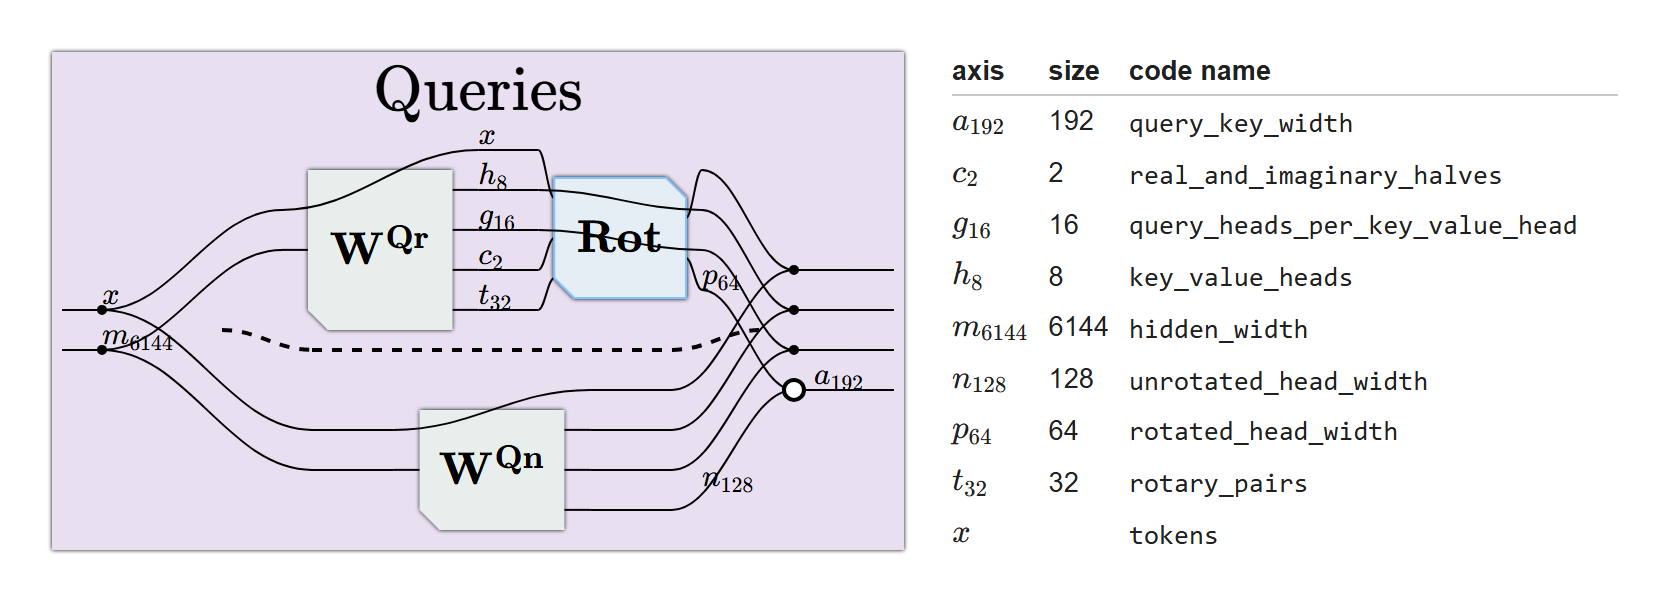

The keys of a sliding window layer at every query and slot: the projections of the turned and the other channels of every key head, the turn at the position of the token read back from the query, and the join onto a.


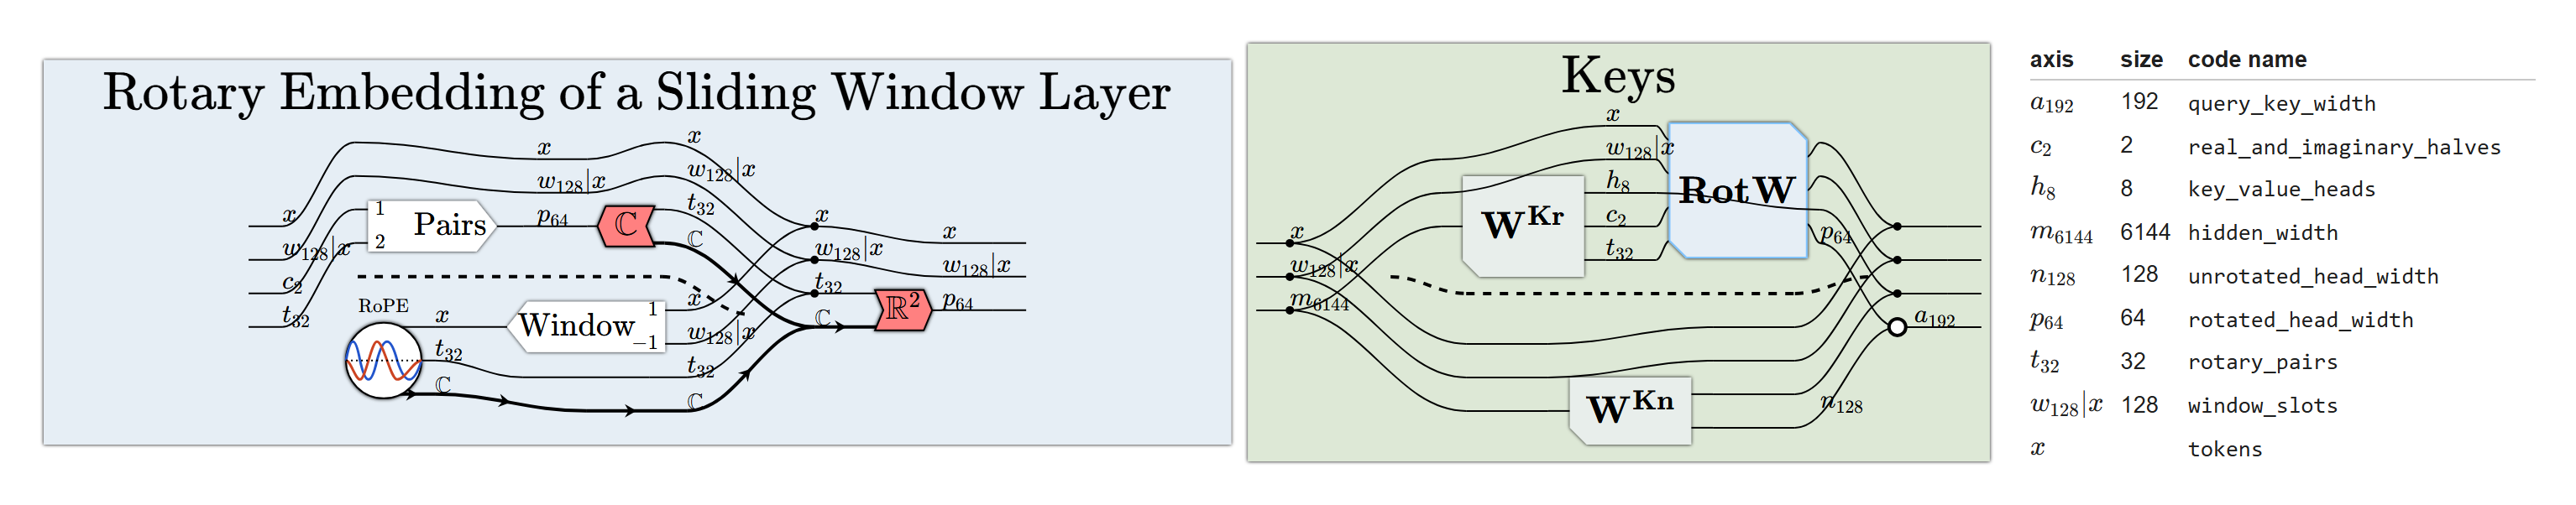

In [4]:
await figures.show(
    whole_model.part_titled(text.QUERY_TITLE, DECODE),
    'The queries: the projection of the turned channels of every query head onto the '
    'two halves, their turn once per head, the projection of the other channels, and '
    'the join onto a.',
    width=1400, assigned_sizes=assigned_sizes, settings=DIAGRAMS)

await figures.show(
    whole_model.part_titled(text.KEY_TITLE, whole_model.part_named('SWA', DECODE)),
    'The keys of a sliding window layer at every query and slot: the projections of the '
    'turned and the other channels of every key head, the turn at the position of the '
    'token read back from the query, and the join onto a.',
    width=1400, assigned_sizes=assigned_sizes, settings=DIAGRAMS)

## The two attention cores

The attention core of a full attention layer is one box computed once per query. Every query head scores against the key of its group at every distance, the score is multiplied by $\lvert a \rvert^{-1/2} = 192^{-1/2}$ ([L84](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L84), [L261](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L261)), a softmax over the distances gives the weights, and the weights sum the values of 128 channels ([L94](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L94), [L100](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L100)). The reference subtracts the largest score before the softmax ([L93](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L93)), which changes no value, and the expression writes the softmax alone.

The core of a sliding window layer adds a learned logit of every query head, `attention_sink_bias`, to the softmax ([L268-L275](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L268-L275), [config.json L2-L3](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L2-L3)). The reference concatenates the logit to the scores of every query, takes the softmax over the 128 slots and the logit, and drops the column of the logit ([L89-L97](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L89-L97)). The expression writes that softmax out. The exponentials of the scores over the slots are summed, the exponential of the logit is added to the sum, and every exponential of a score is divided by the total:

$$p[i_{h}, i_{g}, i_{w}] = \frac{e^{s[i_{h}, i_{g}, i_{w}]}}{\sum_{j_{w} \in w} e^{s[i_{h}, i_{g}, j_{w}]} + e^{\sigma[i_{h}, i_{g}]}}.$$

The logit is called an attention sink. It carries no value, so a head can give most of its weight to the sink and take little from the window. The exponential of the logit is the same for every query, so it is computed once outside the box, which is computed once per query. The full attention layers hold no sink, because `add_full_attention_sink_bias` is false. The reference replaces SDPA with its eager attention whenever a layer holds a sink ([L326-L330](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L326-L330)).

The attention core of a full attention layer, one box computed once per query: the scores of the 128 query heads against the key of their group, the scale, the softmax over the distances and the sum of the values under it.


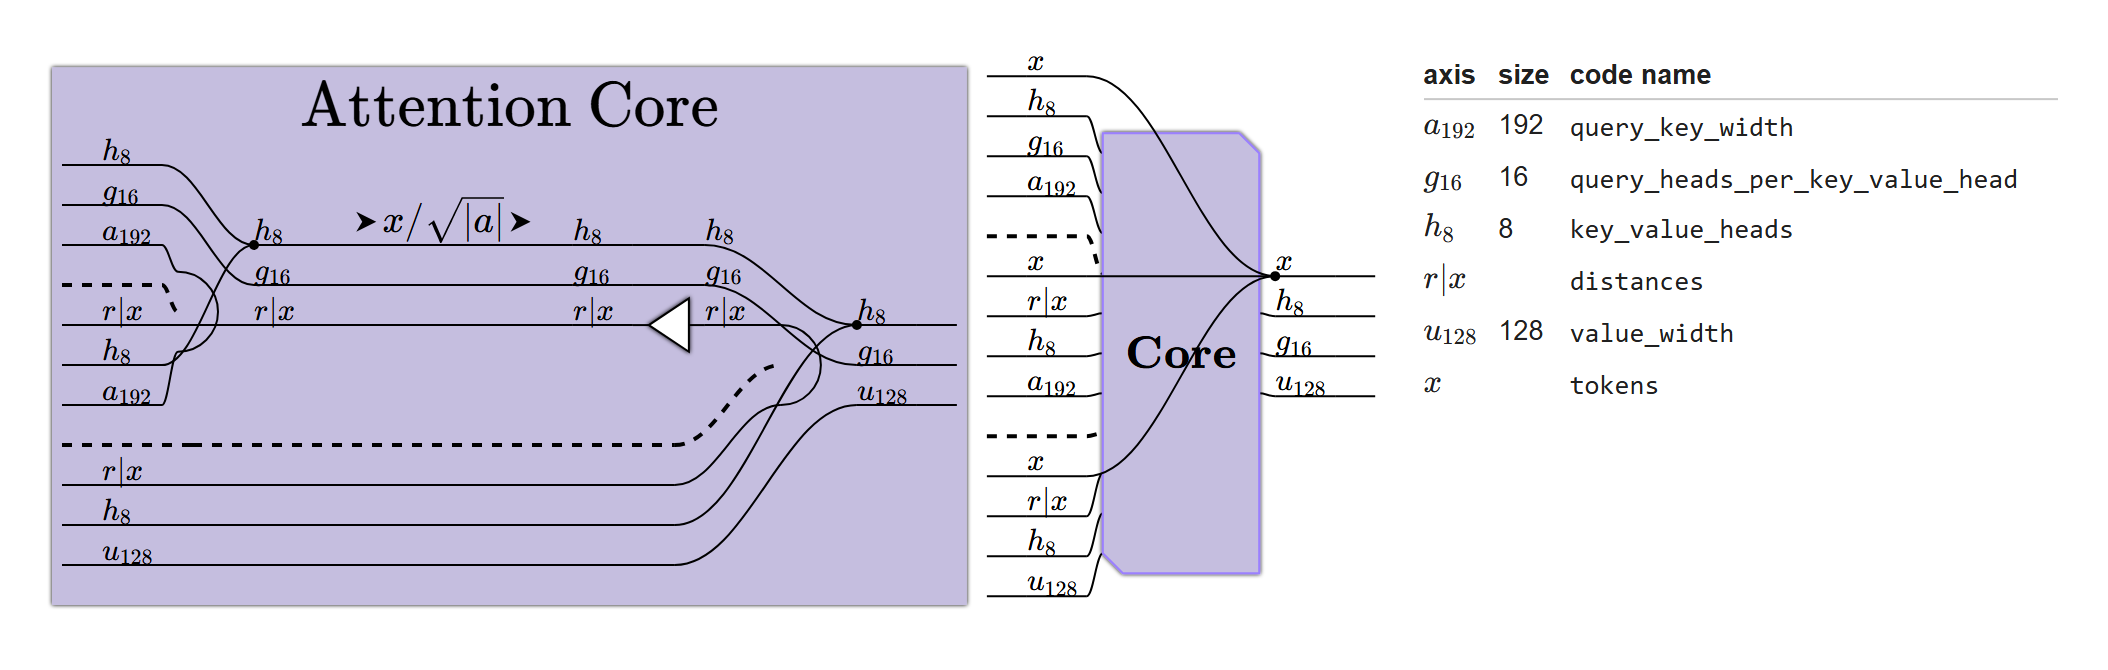

The attention core of a sliding window layer, one box computed once per query: the exponentials of the scaled scores, their sum over the window, the exponential of the sink added to the sum, the reciprocal of the total, and the values weighted by the quotients.


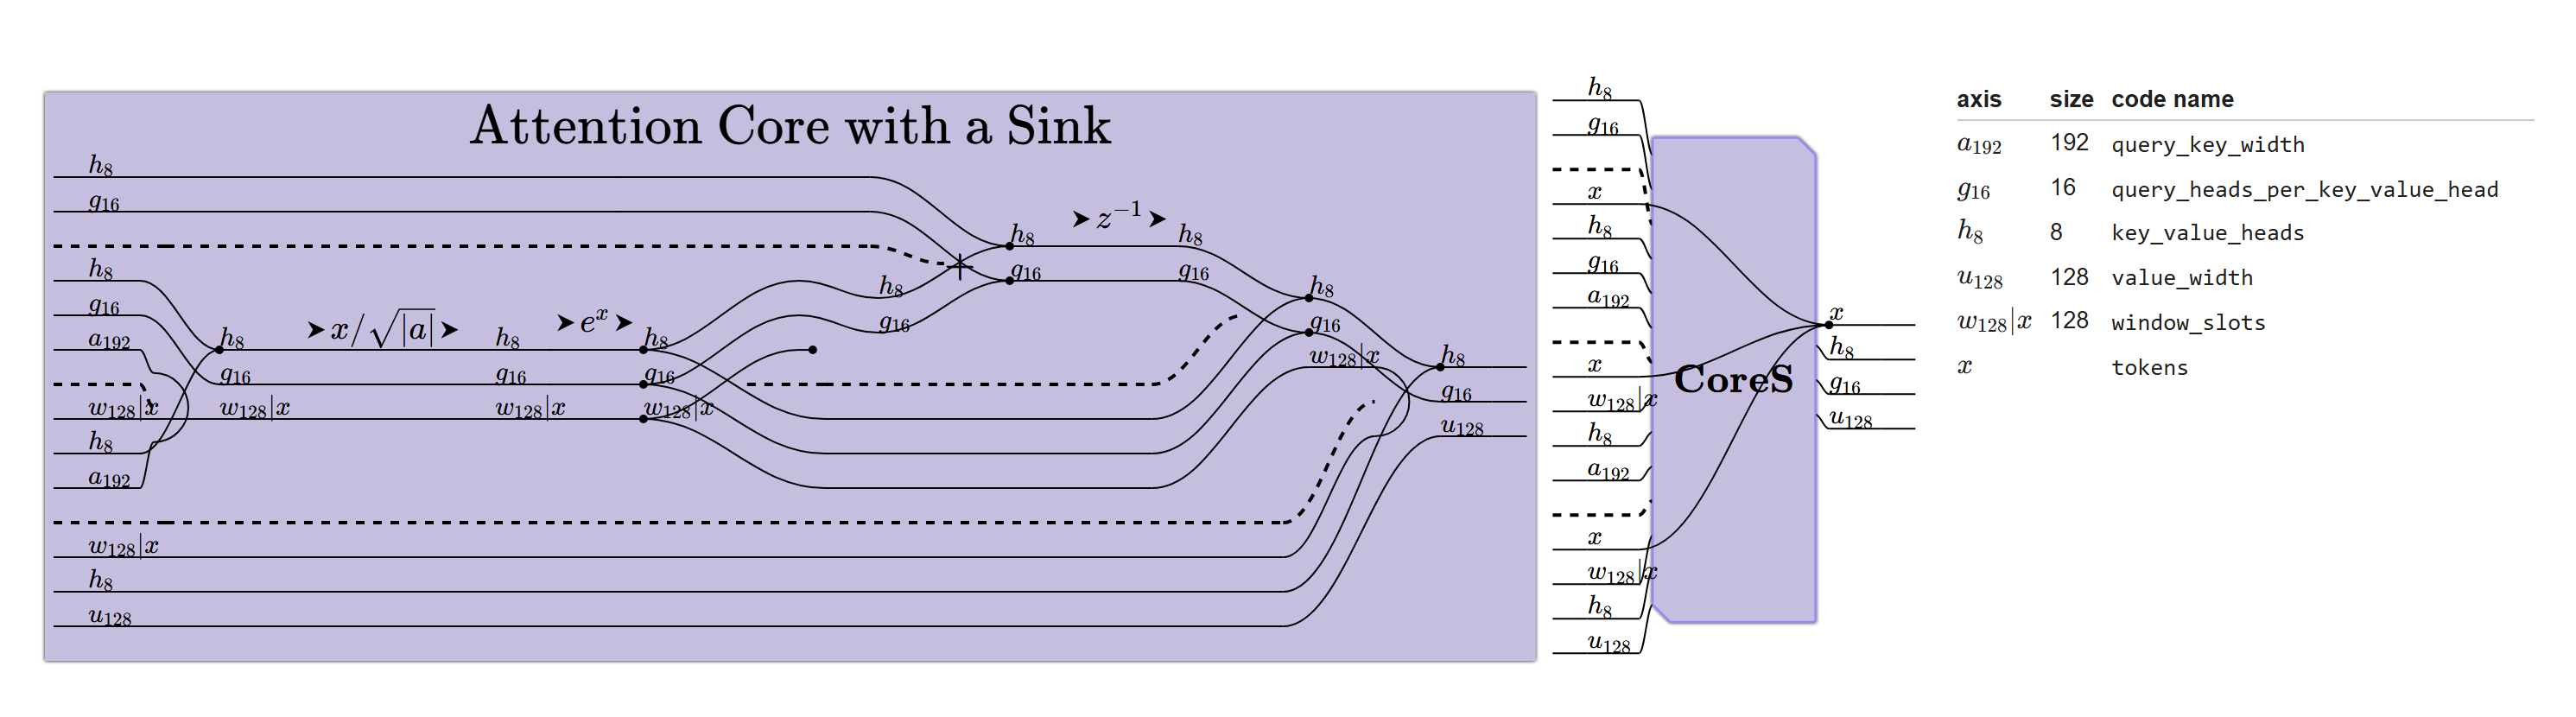

In [5]:
await figures.show(
    whole_model.part_named('Core', DECODE),
    'The attention core of a full attention layer, one box computed once per query: the '
    'scores of the 128 query heads against the key of their group, the scale, the '
    'softmax over the distances and the sum of the values under it.',
    width=1300, sub_blocks=figures.SubBlocks.EVERY_BODY,
    assigned_sizes=assigned_sizes, settings=DIAGRAMS)

await figures.show(
    whole_model.part_named('CoreS', DECODE),
    'The attention core of a sliding window layer, one box computed once per query: the '
    'exponentials of the scaled scores, their sum over the window, the exponential of '
    'the sink added to the sum, the reciprocal of the total, and the values weighted by '
    'the quotients.',
    width=1500, sub_blocks=figures.SubBlocks.EVERY_BODY,
    assigned_sizes=assigned_sizes, settings=DIAGRAMS)

## Full attention and sliding window attention

`hybrid_layer_pattern` gives every layer one of two modes ([config.json L47-L118](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L47-L118), [L400-L404](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L400-L404)). A full attention layer reads its keys and its values back through the view named Back, turns its queries and keys by the table at the base $\beta$, and runs the core without a sink. A sliding window layer reads its keys and its values through the view named Window, turns them by the table at the base $\beta_{\mathrm{w}}$, and runs the core with the sink. The configuration declares the same heads and head widths for both modes ([config.json L370-L374](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L370-L374)). In both modes the output projection $W^{O}$ maps the 128 query heads of 128 channels back onto the hidden width ([L288](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L288), [L354-L355](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L354-L355)).

In both modes the one read back from every query stands at the copy of the normalised hidden state that feeds the queries, the keys and the values.

Full attention: the queries, the hidden state read back from every query, the keys and the values at every query and distance, the core and the output projection.


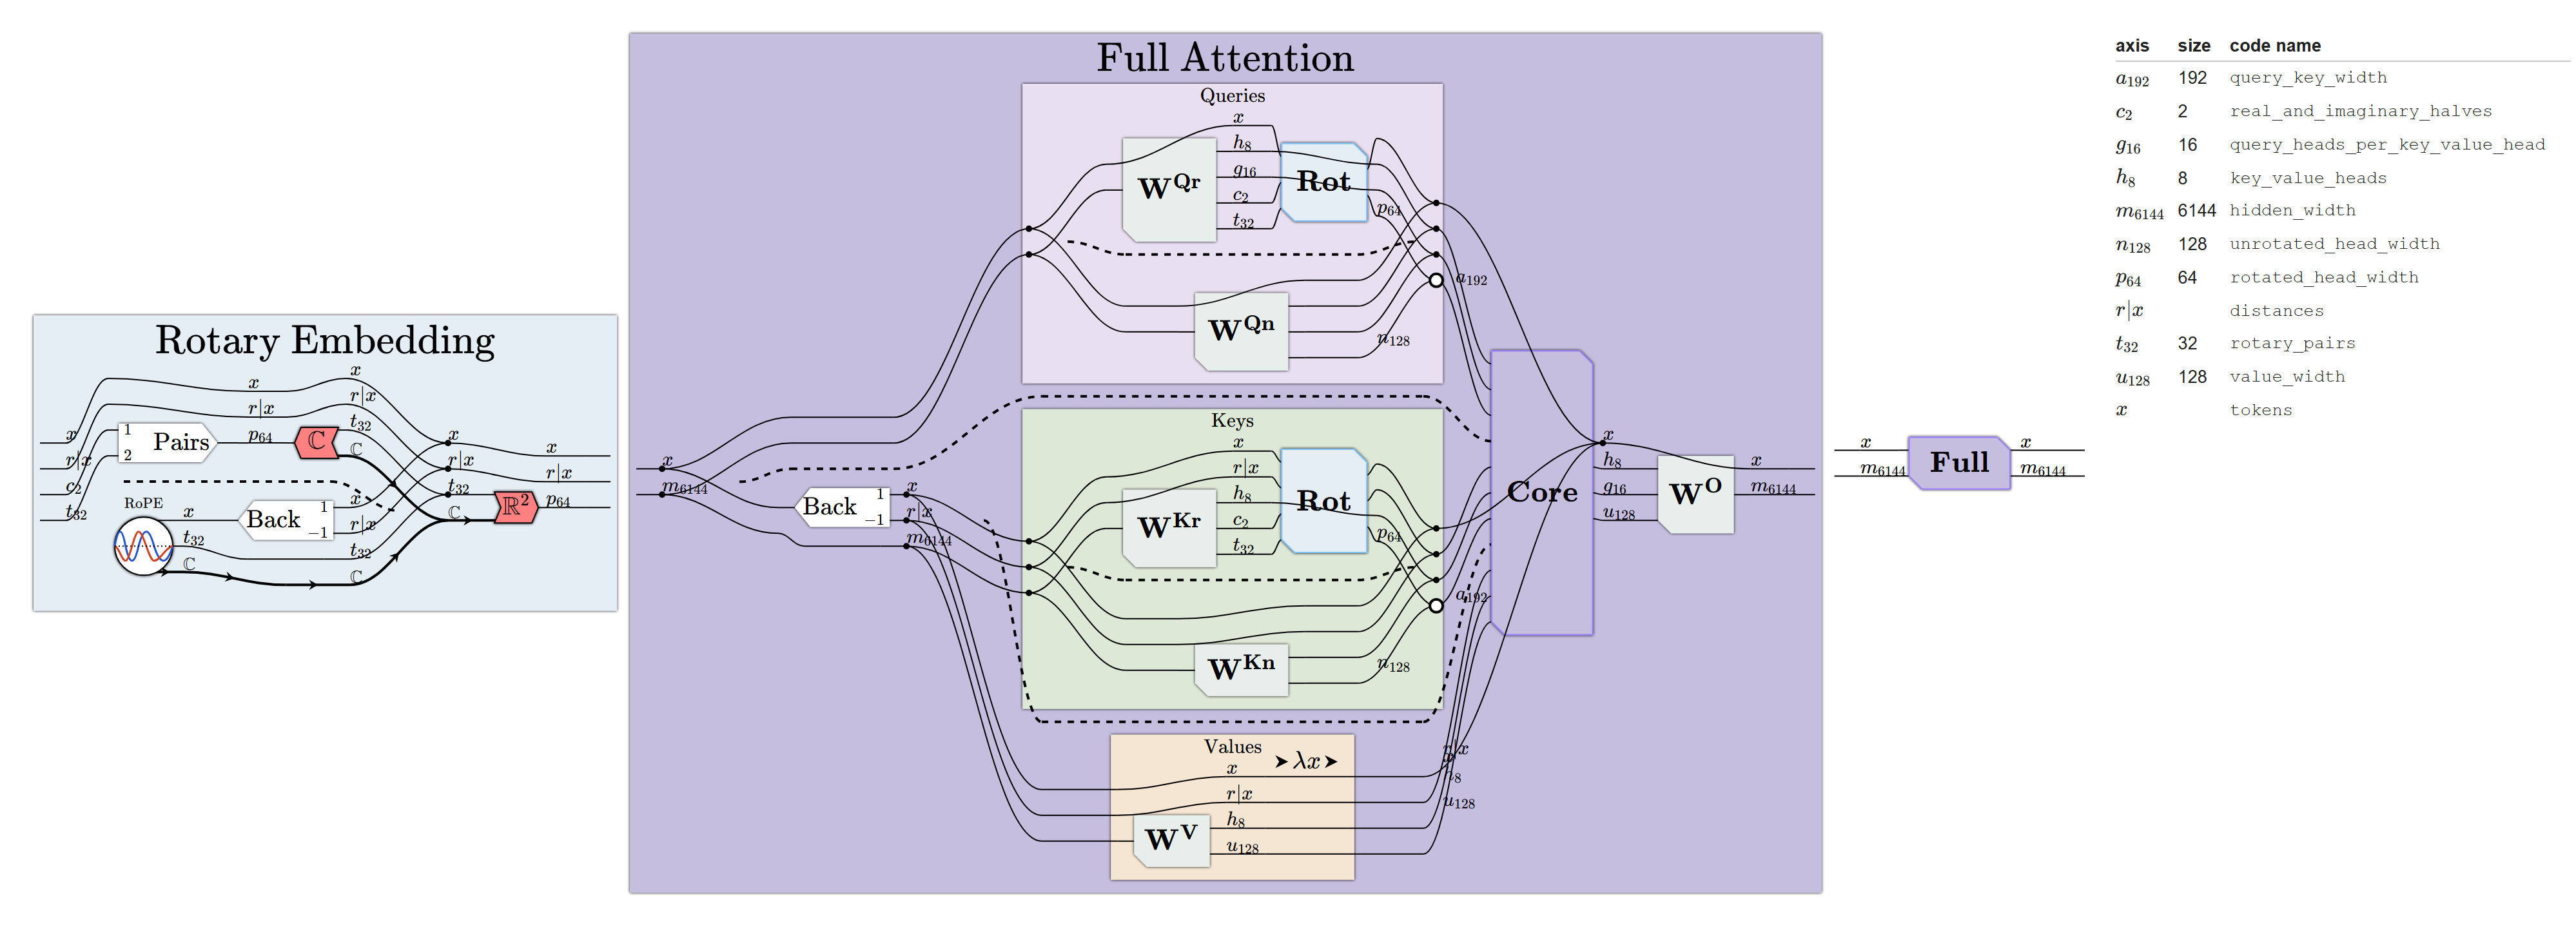

Sliding window attention: the hidden state read back over the 128 slots of the window, the logit of every query head exponentiated once, the core with the sink and the output projection.


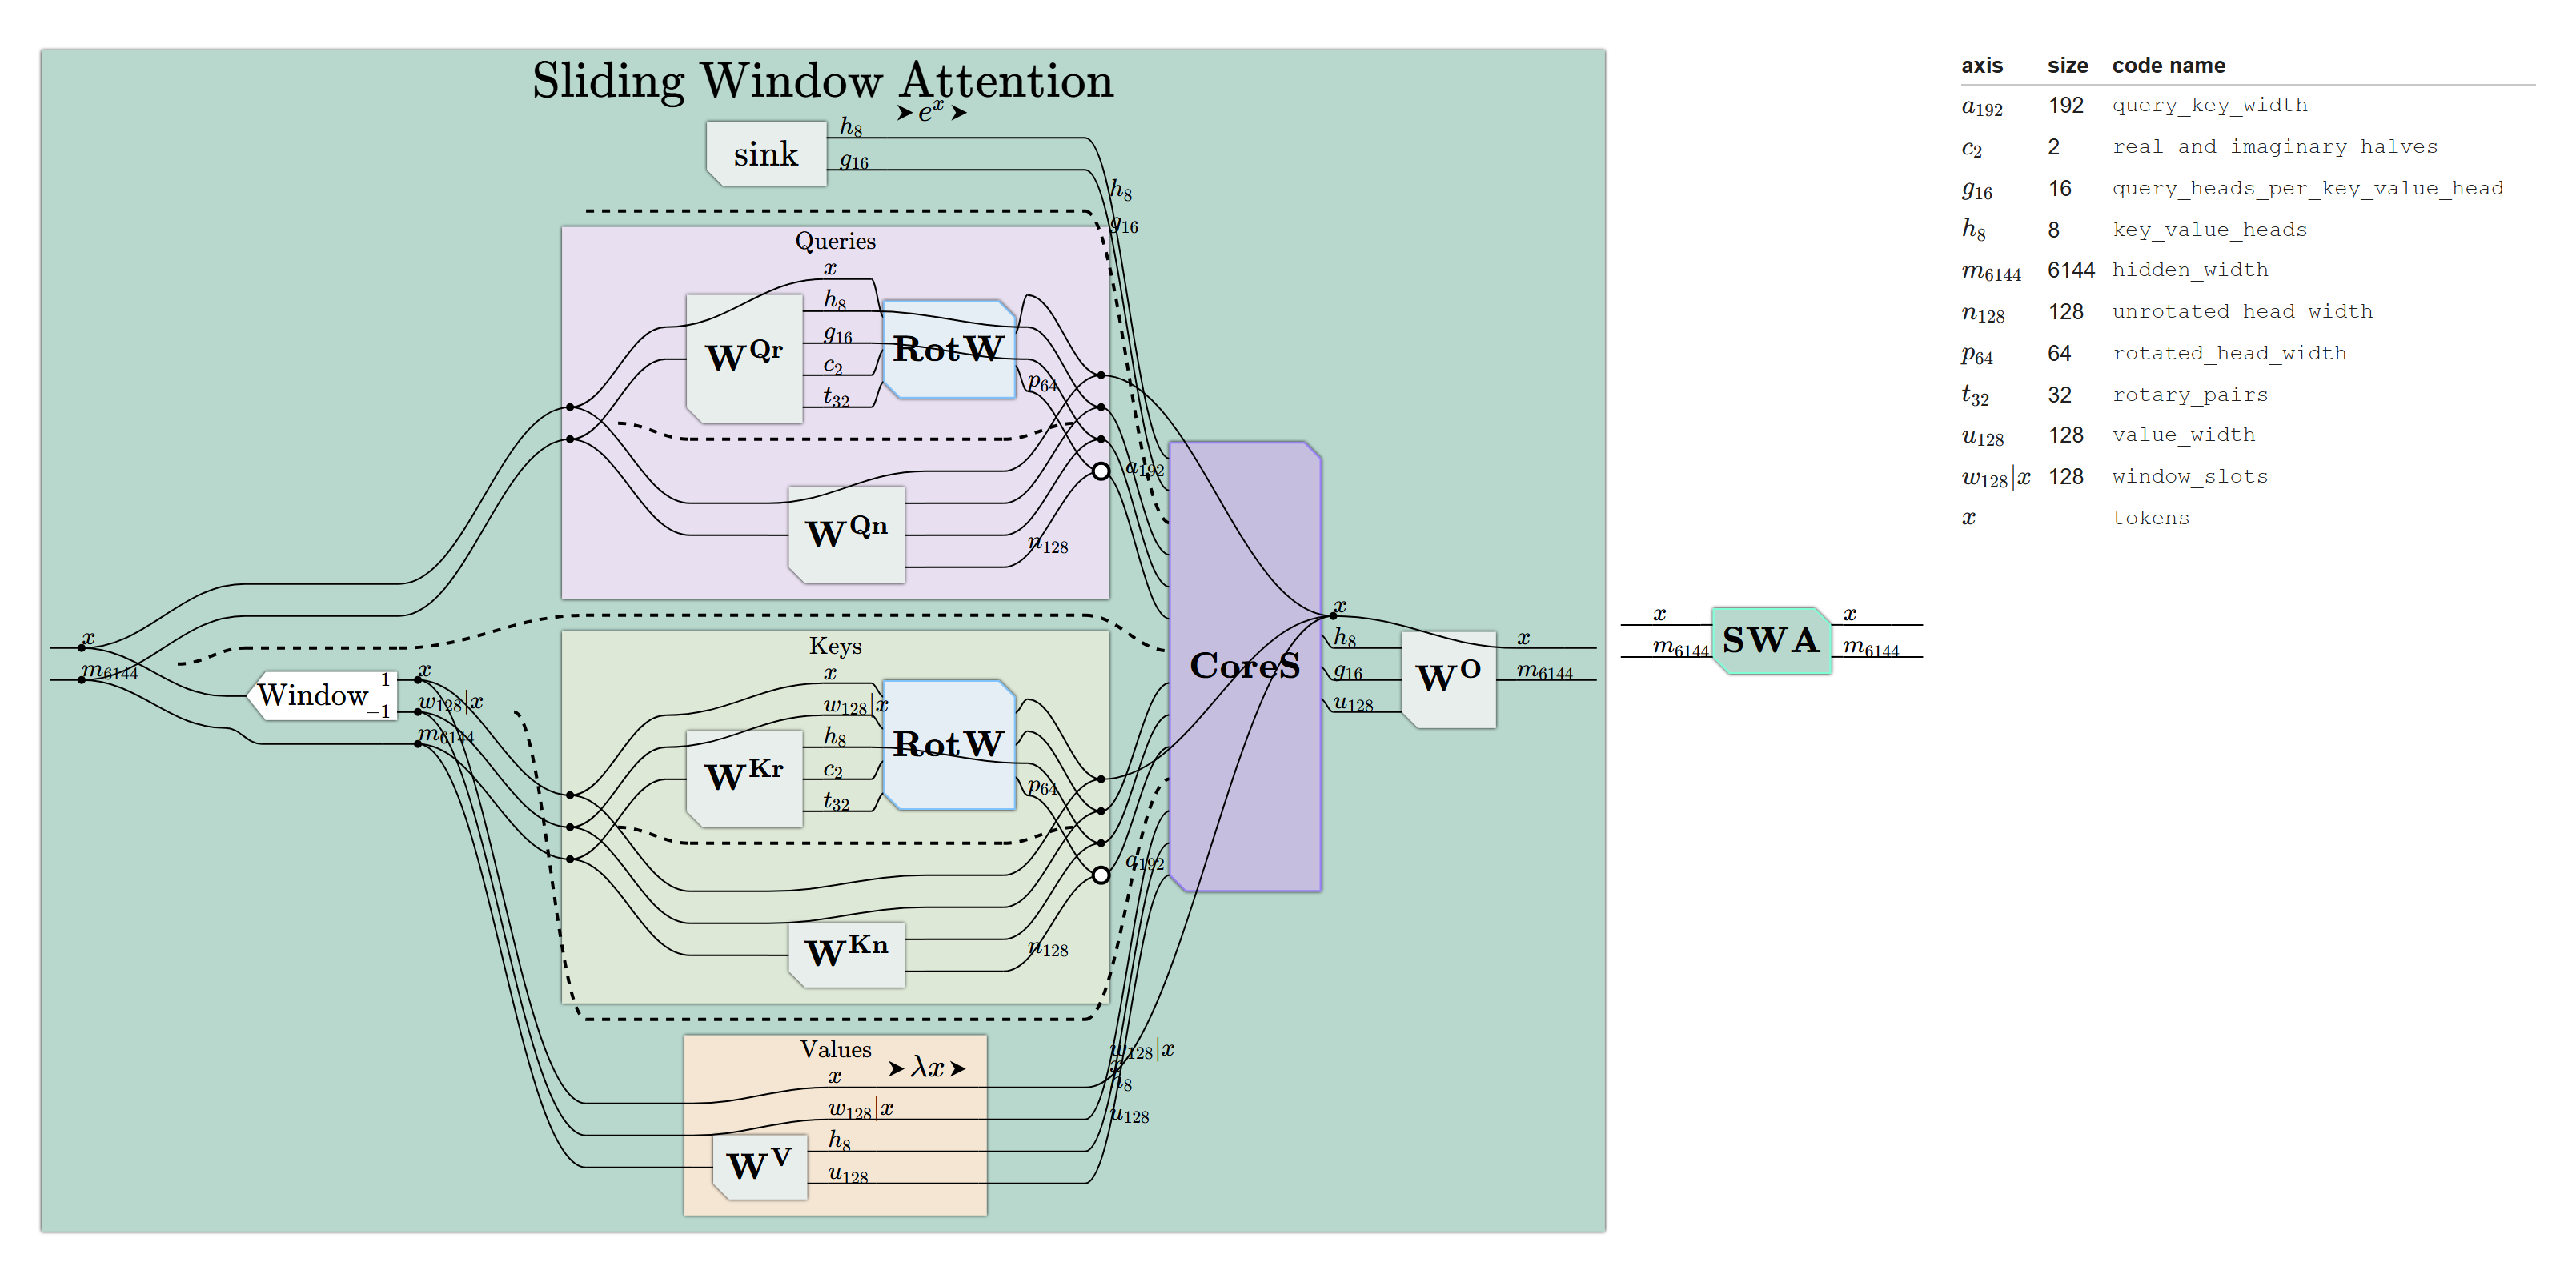

In [6]:
await figures.show(
    whole_model.part_named('Full', DECODE),
    'Full attention: the queries, the hidden state read back from every query, the keys '
    'and the values at every query and distance, the core and the output projection.',
    width=2000, assigned_sizes=assigned_sizes, settings=DIAGRAMS)

await figures.show(
    whole_model.part_named('SWA', DECODE),
    'Sliding window attention: the hidden state read back over the 128 slots of the '
    'window, the logit of every query head exponentiated once, the core with the sink '
    'and the output projection.',
    width=2000, assigned_sizes=assigned_sizes, settings=DIAGRAMS)

## The dense MLP and the mixture of experts

The feed-forward sublayer of layer 0 is a dense SwiGLU of width 16,384, and the feed-forward sublayer of every later layer is a mixture of experts ([L405-L409](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L405-L409), [config.json L126-L197](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L126-L197), [config.json L121](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L121)). A SwiGLU projects the hidden state twice, multiplies the SiLU of the first projection by the second, and projects the product back onto the hidden width ([L120-L132](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L120-L132)).

The router scores all 384 experts with a sigmoid of a linear map of the hidden state ([L155-L157](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L155-L157)). A learned correction bias is added to one copy of the scores, and the 8 experts with the largest biased scores run ([L164](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L164), [L175](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L175)). The other copy holds no bias and is read at the 8 kept experts, so the bias decides which experts run and never scales their outputs ([L176](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L176)). The 8 gates are divided by their sum plus $\varepsilon_{\mathrm{r}} = 10^{-20}$ ([L180-L182](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L180-L182)). The reference first restricts the choice to the best groups of experts, and the configuration sets one group and keeps it ([config.json L198](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L198), [config.json L376](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L376)), so the restriction keeps every expert and the expression leaves it out ([L165-L174](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L165-L174)). The reference multiplies the gates by `routed_scaling_factor`, which the configuration leaves unset and the router replaces by 1 ([config.json L366](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L366), [L141](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L141)), so the expression holds no factor for it.

The expression marks the kept experts with the indicator of a positive biased score and reads the unbiased scores there. The reference gathers the unbiased scores at the kept experts and tests no sign. The two agree when every kept expert has a positive biased score. In every one of the 69 mixtures of the checkpoint at least 344 of the 384 correction biases are positive, and a sigmoid score is positive, so at least 344 biased scores are positive for every token and every kept expert has a positive biased score. The biases lie between -0.349 and 0.810, as read from [model_pp0_ep0_shard0.safetensors](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/model_pp0_ep0_shard0.safetensors) on 2026-09-28.

Each routed expert is a SwiGLU of width 2,048 ([L191-L193](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L191-L193)). Its weights produce the expert axis, so the implicit weight of each projection holds all 384 experts, and a diagonalisation after the down projection keeps the output of the expert chosen at each slot. The gates multiply the outputs of the experts after the down projection, as in the reference ([L205-L208](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L205-L208)), and one contraction over the 8 slots multiplies and sums. The mixture holds no shared expert ([config.json L200](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L200)). The dense MLP and the mixture are each one box computed once per token.

The dense MLP of layer 0, one SwiGLU of width 16384 computed once per token.


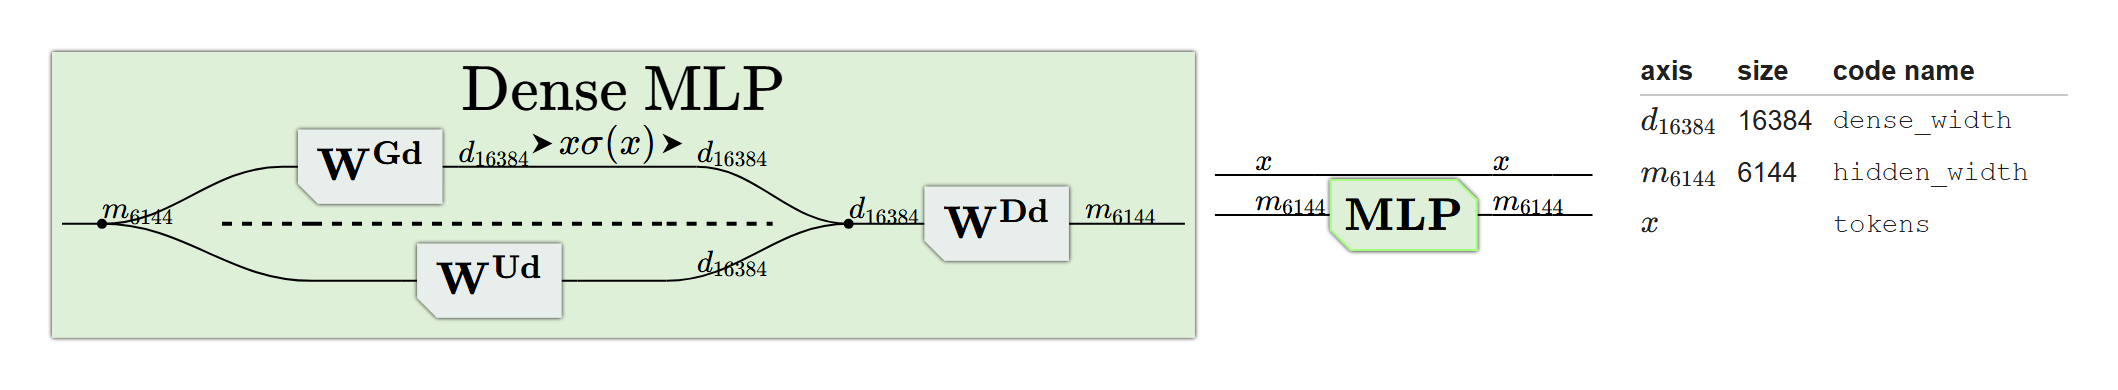

The mixture of experts of one token. The Gate box runs from the router weight to the 8 normalised gates, the correction bias is added on one copy of the scores and chooses the 8 experts, the unbiased copy is read at the experts chosen by it, each expert is a SwiGLU whose down projection is diagonalised at its own expert, and one contraction over the 8 live slots multiplies the outputs by the gates and sums them.


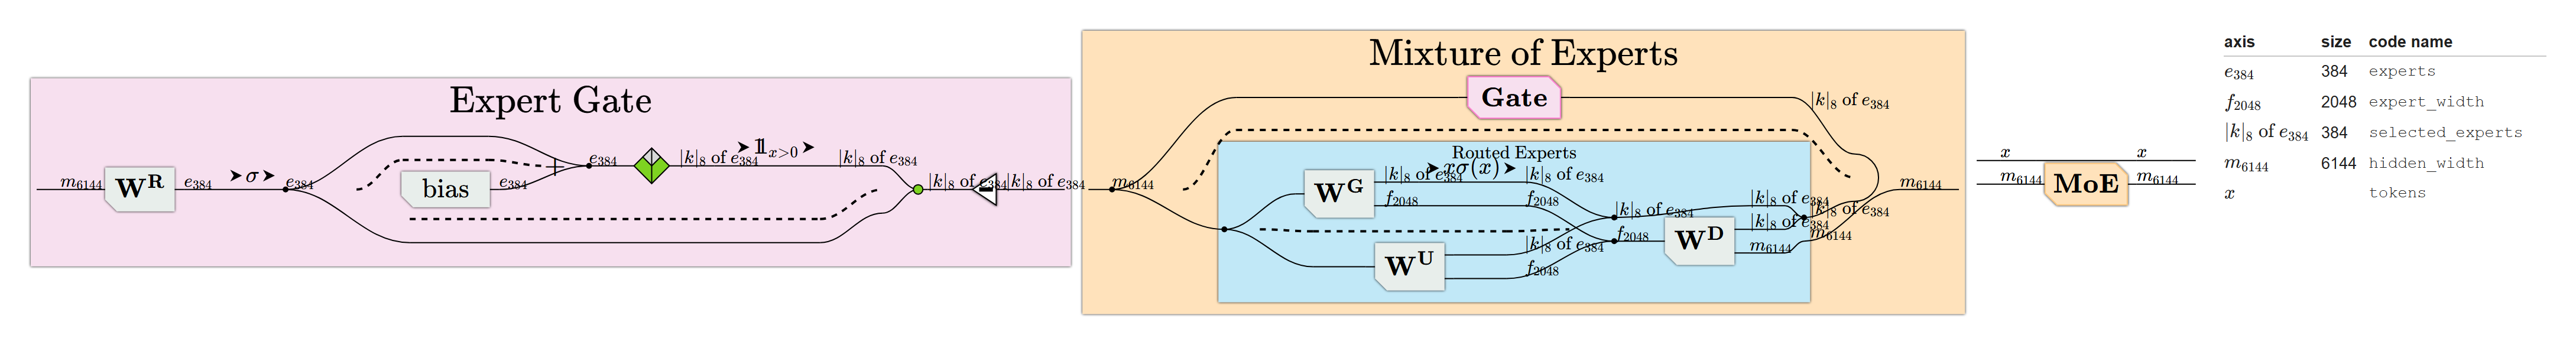

In [7]:
await figures.show(
    whole_model.part_named('MLP', DECODE),
    'The dense MLP of layer 0, one SwiGLU of width 16384 computed once per token.',
    width=1200, assigned_sizes=assigned_sizes, settings=DIAGRAMS)

await figures.show(
    whole_model.part_named('MoE', DECODE),
    'The mixture of experts of one token. The Gate box runs from the router weight to '
    'the 8 normalised gates, the correction bias is added on one copy of the scores and '
    'chooses the 8 experts, the unbiased copy is read at the experts chosen by it, each '
    'expert is a SwiGLU whose down projection is diagonalised at its own expert, and '
    'one contraction over the 8 live slots multiplies the outputs by the gates and sums '
    'them.',
    width=1800, assigned_sizes=assigned_sizes, settings=DIAGRAMS)

## The 70 layers

Every layer is an attention sublayer and a feed-forward sublayer, each inside a pre-norm residual. The residual normalises the hidden state with an RMS normalisation, passes the result through the sublayer, and adds the output to the hidden state from before the normalisation ([L394-L442](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L394-L442)). The full attention layers are 0, 7, 15, 23, 31, 39, 47, 55, 62 and 69 ([config.json L47-L118](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L47-L118)), and the plan is written as four blocks. Layer 0 is a full attention layer with the dense MLP. Layers 1 to 7 are six sliding window layers followed by one full attention layer. Layers 8 to 55 are one block at repetition 6, and each iteration is seven sliding window layers followed by one full attention layer. Layers 56 to 69 are one block at repetition 2, and each iteration is six sliding window layers followed by one full attention layer. Every layer after layer 0 holds the mixture of experts. The counts add to $1 + (6 + 1) + 6 \times (7 + 1) + 2 \times (6 + 1) = 70$.

The embedding looks the token identifiers up in a table of 152,576 rows of 6,144 channels ([L1584](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1584), [L1627-L1628](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1627-L1628)). After the last layer the hidden state is normalised, and the output head maps it onto a logit for every entry of the vocabulary ([L1677](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1677), [L1704](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1704), [L1849-L1851](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1849-L1851)). The output head has a weight of its own, because `tie_word_embeddings` is false ([config.json L375](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L375), [modeling_utils.py L2477-L2481](https://github.com/huggingface/transformers/blob/aad13b87ed59f2afcfaebc985f403301887a35fc/src/transformers/modeling_utils.py#L2477-L2481)). Every RMS normalisation of the text model adds $\varepsilon = 10^{-5}$ ([config.json L122](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L122), [L410-L411](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L410-L411), [L1595](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1595)). The reference returns the logits. The generation configuration sets a temperature of 1 and a top-p of 0.95 and leaves sampling off by default ([generation_config.json L3-L6](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/generation_config.json#L3-L6)), and the model card recommends sampling at those values ([README L205](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/README.md#L205)).

The whole model, drawn with the body of every box left out: the embedding, layer 0, the four blocks of the plan and the output logits.


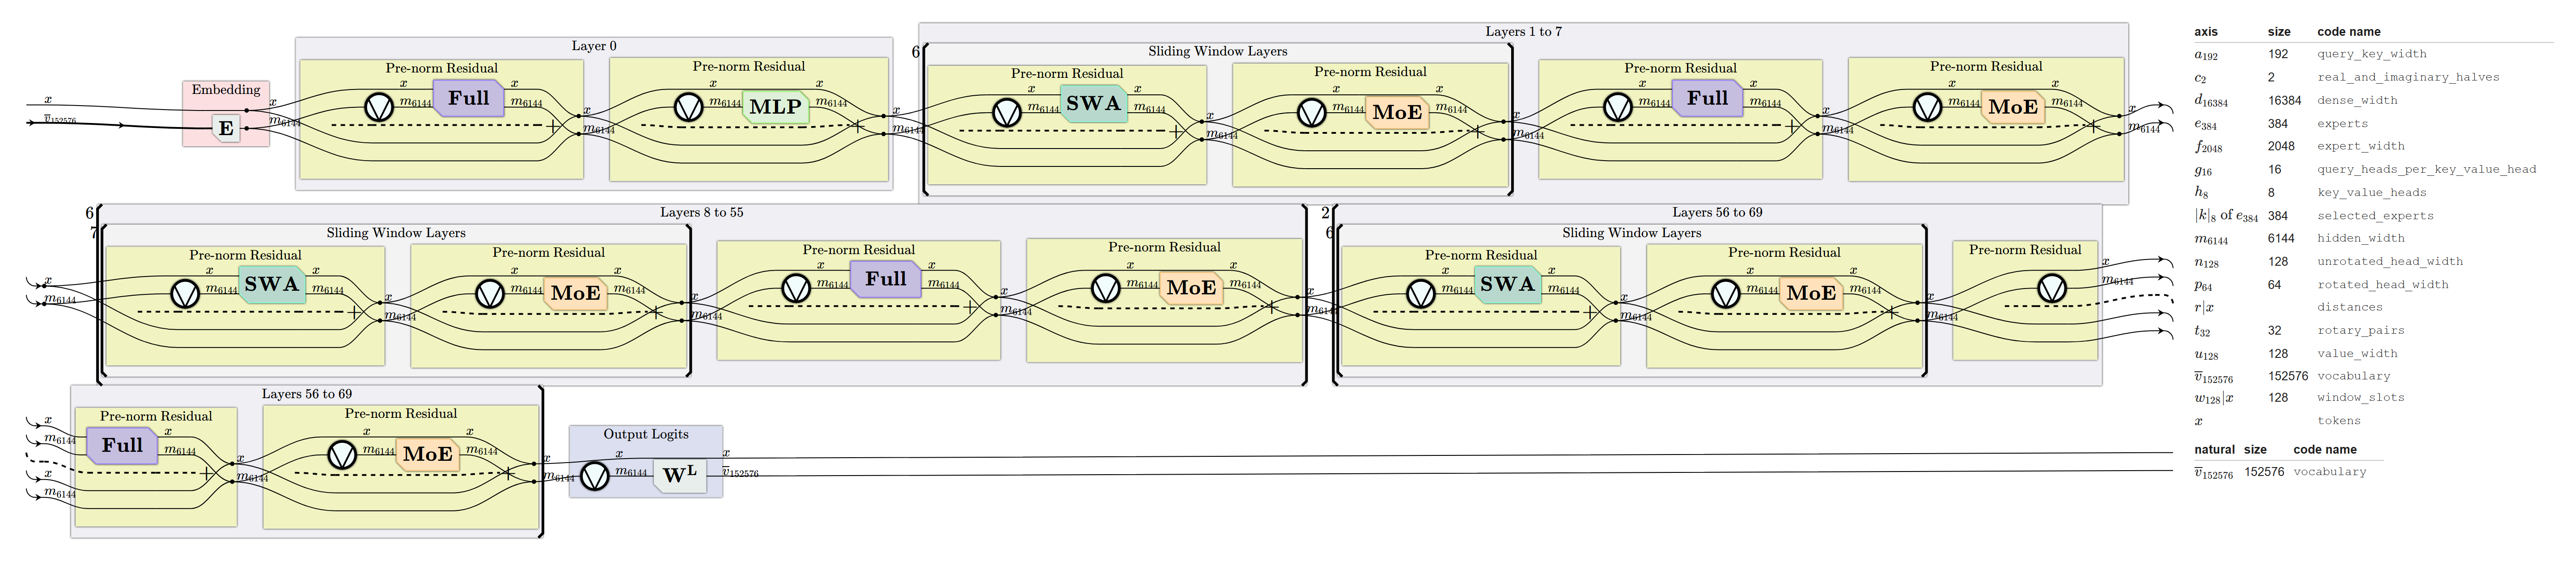

In [8]:
await figures.show(
    DECODE,
    'The whole model, drawn with the body of every box left out: the embedding, layer 0, '
    'the four blocks of the plan and the output logits.',
    width=2300, sub_blocks=figures.SubBlocks.NO_BODIES,
    assigned_sizes=assigned_sizes, settings=DIAGRAMS)

## The number formats of the checkpoint

The figures state the arithmetic of the model in the reals. The checkpoint stores its weights in three formats, and its `quantization_config` names them ([config.json L275-L358](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L275-L358)). The attention projections `qkv_proj` and the dense MLP of layer 0 are E4M3 with FP32 scales, and the configuration names blocks of 128 by 128 weights ([config.json L354-L357](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L354-L357)). The output projections `o_proj`, the router, the embedding, the output head, the normalisations and the sinks are BF16, and the correction biases FP32. The routed experts are stored as MXFP4: two FP4 values packed into each byte, `U8 [2048, 3072]` for the gate projection of one expert, with one UE8M0 scale per 32 values, `U8 [2048, 192]` ([model_pp0_ep0_shard0.safetensors](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/model_pp0_ep0_shard0.safetensors), [model_pp0_ep1_shard0.safetensors](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/model_pp0_ep1_shard0.safetensors), read on 2026-09-28). The configuration names that store with `store_dtype: mxfp4` and `mxfp4_block_size: 32` ([config.json L351-L353](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L351-L353)), and lists every `o_proj` under `ignored_layers` ([config.json L278-L350](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L278-L350)).

`transformers` 5.3.0 reads the entry through `quant_method: fp8` into a `FineGrainedFP8Config` ([quantizers/auto.py L90](https://github.com/huggingface/transformers/blob/aad13b87ed59f2afcfaebc985f403301887a35fc/src/transformers/quantizers/auto.py#L90), [quantizers/auto.py L116](https://github.com/huggingface/transformers/blob/aad13b87ed59f2afcfaebc985f403301887a35fc/src/transformers/quantizers/auto.py#L116)). The constructor keeps `activation_scheme`, `weight_block_size`, `dequantize` and `modules_to_not_convert`, and passes every other key to `**kwargs` without storing it, so `store_dtype`, `mxfp4_block_size` and `ignored_layers` are read by nothing ([utils/quantization_config.py L1807-L1820](https://github.com/huggingface/transformers/blob/aad13b87ed59f2afcfaebc985f403301887a35fc/src/transformers/utils/quantization_config.py#L1807-L1820)). Before the weights load, the quantizer replaces every module whose name ends in `.experts` with an `FP8Expert` and every other `nn.Linear` with an `FP8Linear` ([quantizers/quantizer_finegrained_fp8.py L95-L111](https://github.com/huggingface/transformers/blob/aad13b87ed59f2afcfaebc985f403301887a35fc/src/transformers/quantizers/quantizer_finegrained_fp8.py#L95-L111), [integrations/finegrained_fp8.py L718-L763](https://github.com/huggingface/transformers/blob/aad13b87ed59f2afcfaebc985f403301887a35fc/src/transformers/integrations/finegrained_fp8.py#L718-L763)). An `FP8Expert` holds one fused E4M3 tensor `gate_up_proj` of shape `[384, 4096, 6144]` and one `down_proj`, with FP32 block scales ([integrations/finegrained_fp8.py L616-L658](https://github.com/huggingface/transformers/blob/aad13b87ed59f2afcfaebc985f403301887a35fc/src/transformers/integrations/finegrained_fp8.py#L616-L658)). The checkpoint holds one packed tensor per expert and projection, and `transformers` 5.3.0 has no conversion that maps them onto the fused tensors. The mixture of the reference then calls `len(self.experts)` on the `FP8Expert` ([L198](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L198)), which defines no length. `transformers` 5.3.0 therefore does not run the routed experts of this checkpoint, and the notebook draws no quantised form of the model. SGLang and vLLM, which the model card names for deployment, hold loaders of their own for the MXFP4 store, and the notebook does not read them.

## The pass over new tokens and its caches

A pass of generation reads the tokens appended since the pass before and needs the logits of those tokens alone. Write $x_{\mathrm{old}}$ for the tokens of the earlier passes and $x_{\mathrm{new}}$ for the new tokens, which are one token in plain decoding, several in a draft of speculative decoding and the whole prompt in the first pass. The pass needs the results of the model at the positions $\lvert x_{\mathrm{old}} \rvert + i_{\mathrm{new}}$ of the sequence. That read of the token axis is one affine map from $x_{\mathrm{new}}$ to $x$. An operation broadcast over the tokens computes its results at the new tokens from its operands read at the new tokens. The pass is therefore derived by carrying the read back from the logits through the model, and every operation passed by the read is rebuilt over $x_{\mathrm{new}}$.

A read back from every query composes with the read of the new tokens into a read of token $\lvert x_{\mathrm{old}} \rvert + i_{\mathrm{new}} - i_{r}$, which reaches the earlier tokens. The operator `Caching`, drawn as a cylinder, loads the entries a cache holds for the earlier tokens, appends the entries of this pass for the passes after it, and returns the array over the earlier tokens and the new ones. The derivation is run on the model as built, with the reads where the reference applies its masks, and computes no operator over the cache. Every cache therefore holds the operand of a read, which is the keys after the rotary embedding and the join, and the values after the scale, the two arrays the reference hands to its cache ([L312-L314](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L312-L314)).

A full attention layer reads every earlier token, so its caches hold every one. A window of 128 slots reads at most 127 tokens before the first new token, so the derivation gives the caches of a sliding window layer the last $\lvert w \rvert - 1 = 127$ earlier tokens followed by the new ones. The reference keeps the same tokens. `MiMoV2Model` names every sliding window layer `sliding_attention` in `config.layer_types` ([L1599-L1602](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1599-L1602)) and creates a `DynamicCache` from the configuration ([L1630-L1631](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1630-L1631)). `DynamicCache` gives every layer of that name a `DynamicSlidingWindowLayer`, which keeps the last `sliding_window - 1` tokens ([cache_utils.py L958-L979](https://github.com/huggingface/transformers/blob/aad13b87ed59f2afcfaebc985f403301887a35fc/src/transformers/cache_utils.py#L958-L979), [cache_utils.py L168-L217](https://github.com/huggingface/transformers/blob/aad13b87ed59f2afcfaebc985f403301887a35fc/src/transformers/cache_utils.py#L168-L217)). Each cache is named after the operation it follows, so the keys are cached as $c_{\Vert}$, after the join, and the values as $c_{\lambda x}$, after the scale. The table counts the values held by each layer for one token.

The ten full attention layers hold 25,600 values for every token of the context. The sixty sliding window layers hold 2,560 values for each of at most 127 tokens, 19,507,200 values in all whatever the length of the context. Derived from the CausalSlide, where each read stands on the normalised hidden state, every layer would cache that hidden state, 6,144 values per token, where the keys and the values of 8 heads take 2,560.

| attention mode | layers | caches, with the values each holds per token | earlier tokens kept | values per token of one layer |
|---|---|---|---|---|
| Full | 10 | $c_{\Vert}$ 1,536, $c_{\lambda x}$ 1,024 | every one | 2,560 |
| SWA | 60 | $c_{\Vert}$ 1,536, $c_{\lambda x}$ 1,024 | the last 127 | 2,560 |

The body of sliding window attention over the new tokens, with the body of every box left out. The keys and the values are computed at the new tokens and cached with the last 127 earlier tokens, and the view named Window reads them back from every new query.


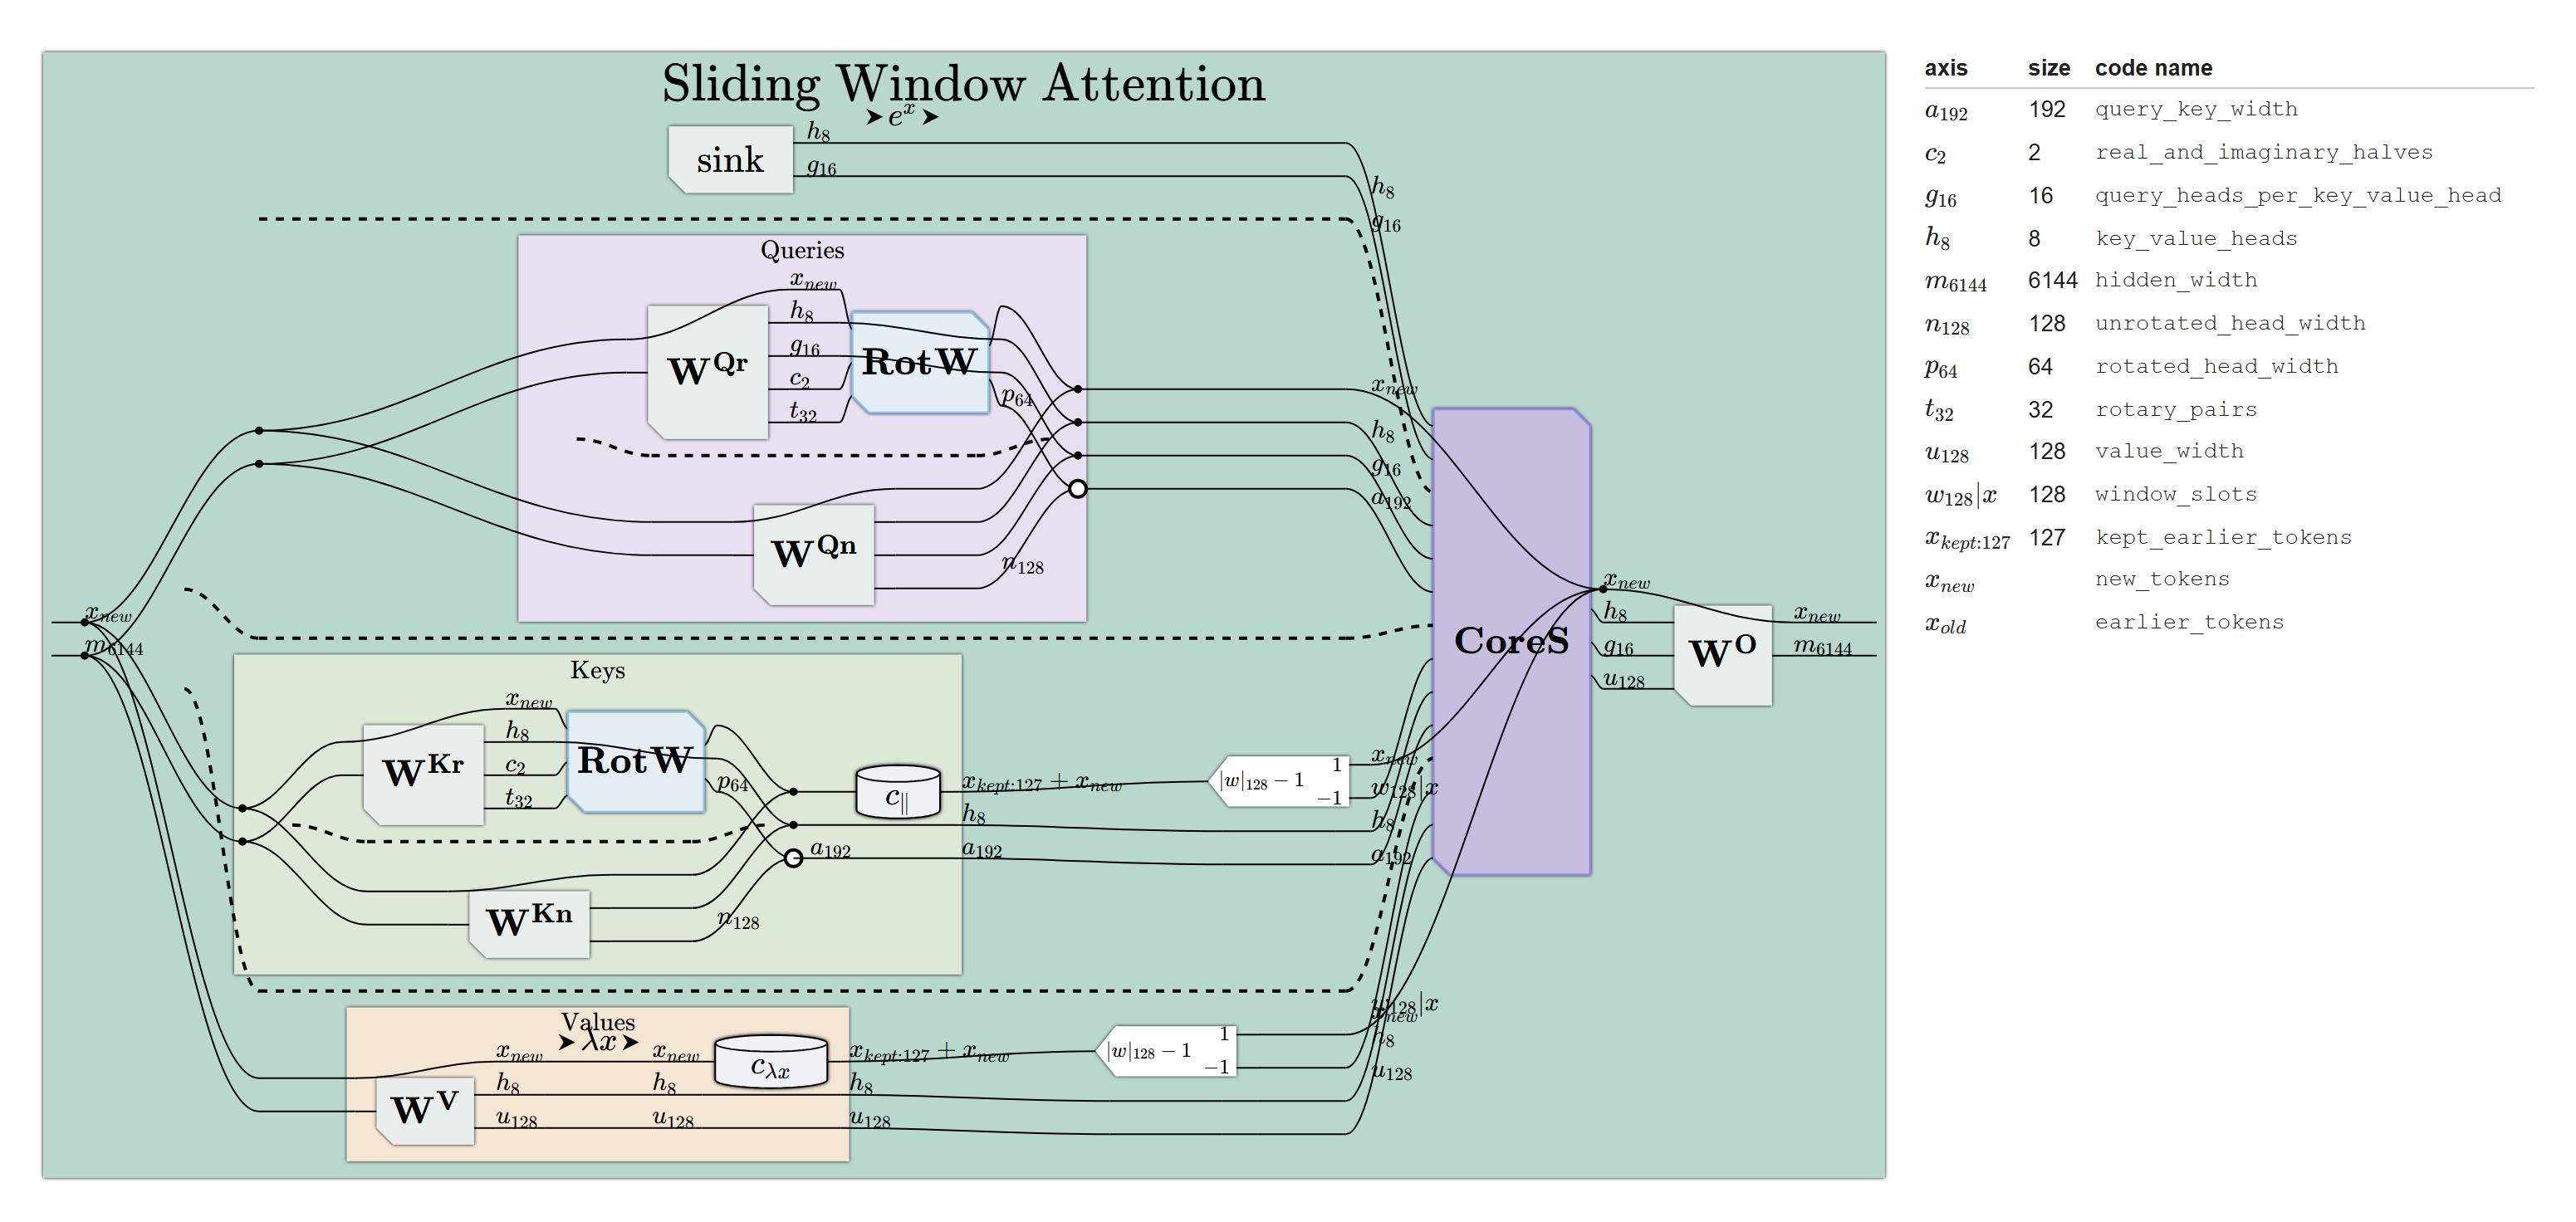

The body of full attention over the new tokens. The keys and the values are cached with every earlier token, and the view named Back reads them back from every new query.


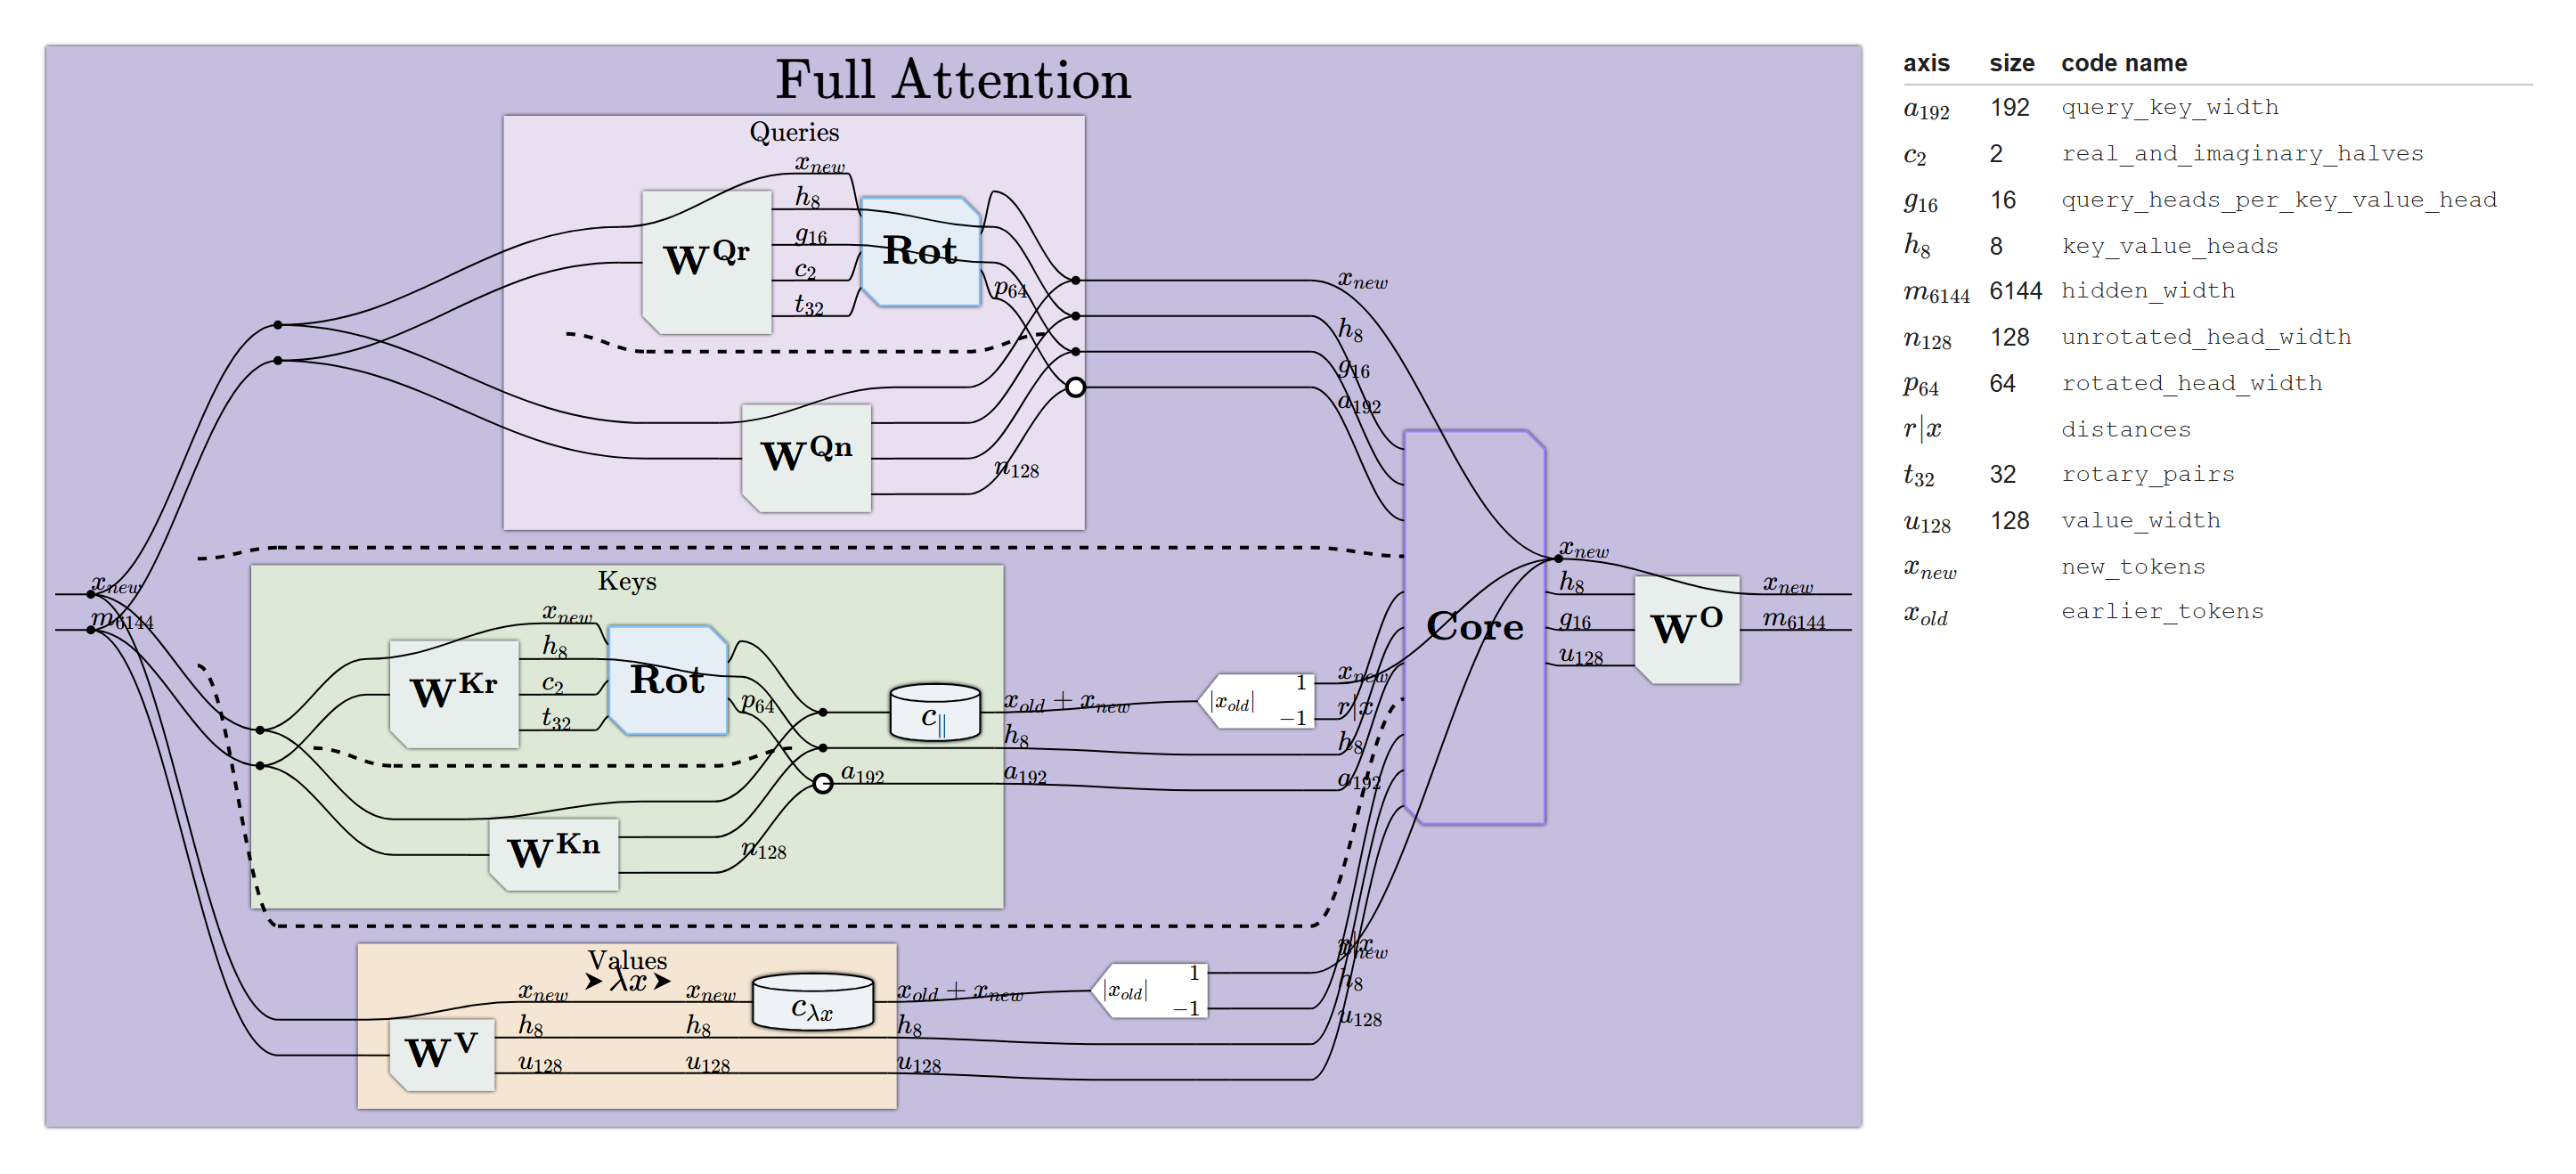

The whole pass over the new tokens, drawn with the body of every box left out. It reads the identifiers of the new tokens and returns their logits.


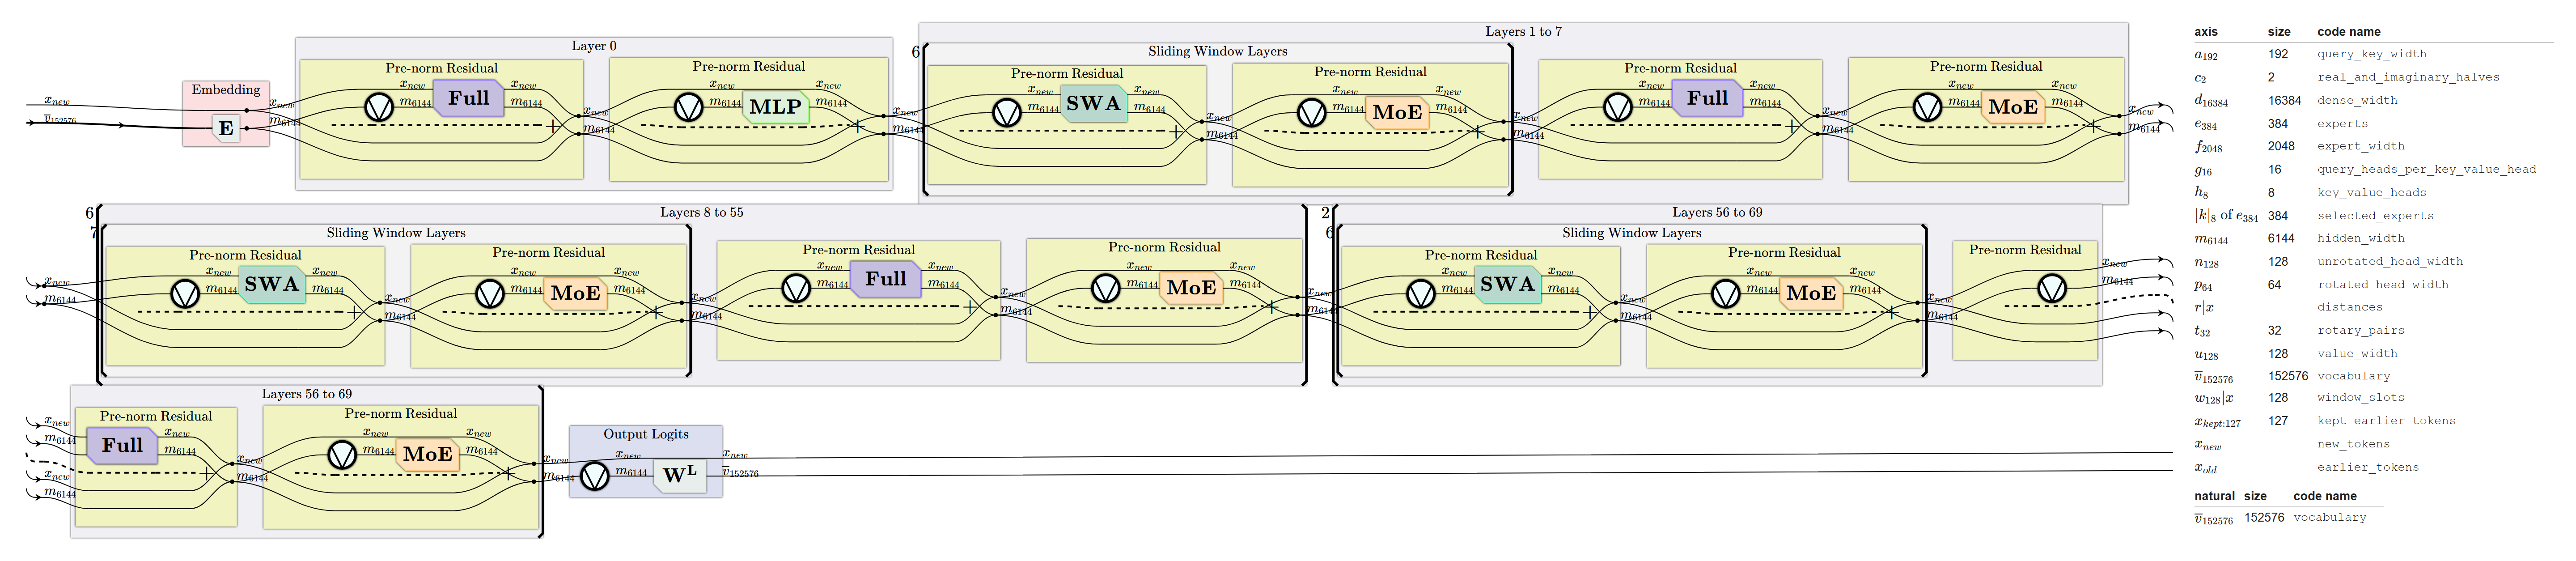

In [9]:
display(Markdown(derive_cached_mimo_v26_pro.cache_table()))

await figures.show(
    whole_model.part_titled(text.WINDOW_TITLE, CACHED),
    'The body of sliding window attention over the new tokens, with the body of every '
    'box left out. The keys and the values are computed at the new tokens and cached '
    'with the last 127 earlier tokens, and the view named Window reads them back from '
    'every new query.',
    width=2200, sub_blocks=figures.SubBlocks.NO_BODIES,
    assigned_sizes=cached_sizes, settings=DIAGRAMS)

await figures.show(
    whole_model.part_titled(text.FULL_TITLE, CACHED),
    'The body of full attention over the new tokens. The keys and the values are cached '
    'with every earlier token, and the view named Back reads them back from every new '
    'query.',
    width=2200, sub_blocks=figures.SubBlocks.NO_BODIES,
    assigned_sizes=cached_sizes, settings=DIAGRAMS)

await figures.show(
    CACHED,
    'The whole pass over the new tokens, drawn with the body of every box left out. It '
    'reads the identifiers of the new tokens and returns their logits.',
    width=2300, sub_blocks=figures.SubBlocks.NO_BODIES,
    assigned_sizes=cached_sizes, settings=DIAGRAMS)

## The two forms on one page

The last cell writes the two forms into `notebooks/website/output/modern/MiMoV26Pro/index.html`, one file that opens with no server and no network. A selector above the figure switches between the model reading every token of the prompt, under Decode, and the pass over new tokens, under Cached. Each group holds the form in the reals, named Unquantised as on the other modern pages, and no quantised form, for the reason given in the section on the number formats of the checkpoint. The page opens on the model, with the legend of its axes and an inspection box over every block, operator, weight and view. Every axis of the legend carries the name it takes in generated code.

In [10]:
await notebook_diagrams.show_page_variants(
    assemble_page_variants.page_variants(PAGE),
    'MiMo-V2.6-Pro as one page: the model and the pass over new tokens, in the reals.',
    settings=PAGE, slug=assemble_page_variants.PAGE_SLUG,
    initial=assemble_page_variants.INITIAL_VARIANT)

MiMo-V2.6-Pro as one page: the model and the pass over new tokens, in the reals.


(written to notebooks/website/output/modern/MiMoV26Pro/)


## Facts left unstated by the figures

- The checkpoint stores the attention projections and the dense MLP in E4M3 with block scales, the routed experts in MXFP4, and the rest in BF16 and FP32 ([config.json L275-L358](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L275-L358)). Every wire of the figures holds reals, and the section on the number formats of the checkpoint states why no quantised form is drawn.
- The vision encoder, the two audio encoders and the replacement of the embeddings of image, video and audio tokens by their outputs are left out ([L1758-L1803](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1758-L1803), [L1827-L1836](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1827-L1836)). The expression is the text path.
- The drafter of five layers for speculative decoding is left out, because the reference skips its weights ([L1690-L1695](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1690-L1695), [README L99](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/README.md#L99)).
- The reference writes the turned pairs of a query head or a key head back as two halves, where `dst.Decomplex` writes each pair back in place ([L58-L59](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L58-L59)). The query and the key are permuted alike, so every score is unchanged, and the cache holds the keys of the reference with their turned channels in the order of the pairs.
- The reference subtracts the largest score of every query before its softmax ([L93](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L93)), which changes no value.
- The expression marks the kept experts by the sign of their biased scores, which agrees with the reference for every token given the correction biases of the checkpoint, as the section on the mixture of experts states.
- The configuration sets `moe_router_dtype` to `bfloat16` and `attention_chunk_size` to 128 ([config.json L39](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L39), [config.json L8](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L8)). The remote code reads neither. `DynamicCache` reads `attention_chunk_size` only where `sliding_window` is unset ([cache_utils.py L960-L962](https://github.com/huggingface/transformers/blob/aad13b87ed59f2afcfaebc985f403301887a35fc/src/transformers/cache_utils.py#L960-L962)).
- The expression holds no batch axis. The reference applies a padding mask to a batch of prompts of different lengths.

## The reference implementation

The reference is `modeling_mimo_v2.py` and `configuration_mimo_v2.py` in the checkpoint `XiaomiMiMo/MiMo-V2.6-Pro-MOPD`, read at the commit `adea8e2c5373` on 2026-09-28, with the `config.json` of the same commit. The masks and the cache come from `transformers` at the tag `v5.3.0`, the commit `aad13b87ed59`. The same links stand in the inspection box over every block on the page.

| mechanism | here | reference | lines |
| --- | --- | --- | --- |
| Embedding and output head | `whole_model.embed`, `whole_model.output_logits` | `embed_tokens`, `norm`, `lm_head` | [L1584](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1584), [L1595](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1595), [L1677](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1677), [L1704](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1704), [L1849-L1851](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1849-L1851) |
| Pre-norm residual | `layer_stack.residual_sublayer` | `MiMoV2DecoderLayer` | [L394-L442](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L394-L442) |
| RMS normalisation | `ops.Normalize` | `MiMoV2RMSNorm` | [L105-L117](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L105-L117) |
| Rotary embedding | `rotary_embedding` | `MiMoV2RotaryEmbedding`, `rotate_half`, `apply_rotary_pos_emb` | [L47-L60](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L47-L60), [L445-L505](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L445-L505), [L306-L310](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L306-L310) |
| Queries, keys and values | `grouped_query_attention.queries`, `keys`, `values` | `qkv_proj`, `v_scale` | [L278-L283](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L278-L283), [L302-L303](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L302-L303), [L370-L380](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L370-L380) |
| Reads of the earlier tokens | `grouped_query_attention.READ_BACK`, `READ_WINDOW` | `create_causal_mask`, `create_sliding_window_causal_mask` | [L1642-L1657](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1642-L1657), [masking_utils.py L90-L99](https://github.com/huggingface/transformers/blob/aad13b87ed59f2afcfaebc985f403301887a35fc/src/transformers/masking_utils.py#L90-L99) |
| Attention cores | `grouped_query_attention.CORE`, `SINK_CORE` | `eager_attention_forward`, `repeat_kv`, `attention_sink_bias` | [L63-L102](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L63-L102), [L268-L275](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L268-L275) |
| Output projection | `grouped_query_attention.output_projection` | `o_proj` | [L288](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L288), [L354-L355](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L354-L355) |
| Attention modes | `attention_modes` | `hybrid_layer_pattern`, `is_swa` | [L220-L391](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L220-L391), [L400-L404](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L400-L404), [config.json L47-L118](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L47-L118) |
| Dense MLP and routed experts | `feed_forward.swiglu` | `MiMoV2MLP` | [L120-L132](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L120-L132) |
| Router | `mixture_of_experts.expert_gate` | `MiMoV2MoEGate` | [L135-L184](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L135-L184) |
| Mixture of experts | `mixture_of_experts.MIXTURE` | `MiMoV2MoE` | [L187-L217](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L187-L217) |
| Layer plan | `layer_stack` | `hybrid_layer_pattern`, `moe_layer_freq` | [config.json L47-L118](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L47-L118), [config.json L126-L197](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/config.json#L126-L197), [L1585-L1594](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1585-L1594) |
| Drafter, left out | none | `_keys_to_ignore_on_load_unexpected` | [L1690-L1695](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1690-L1695) |
| Cache of the pass over new tokens | `derive_cached_mimo_v26_pro` | `DynamicCache`, `DynamicSlidingWindowLayer` | [L1630-L1631](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L1630-L1631), [L312-L314](https://huggingface.co/XiaomiMiMo/MiMo-V2.6-Pro-MOPD/blob/adea8e2c5373181e5a973fa1ecb343cb31af214b/modeling_mimo_v2.py#L312-L314), [cache_utils.py L168-L217](https://github.com/huggingface/transformers/blob/aad13b87ed59f2afcfaebc985f403301887a35fc/src/transformers/cache_utils.py#L168-L217), [cache_utils.py L958-L979](https://github.com/huggingface/transformers/blob/aad13b87ed59f2afcfaebc985f403301887a35fc/src/transformers/cache_utils.py#L958-L979) |